# 🔐 OWASP Agentic AI Top 10 — SLR Literature Synthesis & Visualization

**Paper:** Systematic Literature Review on Agentic AI Security Threats

This notebook contains:
1. **Complete dataset** of 75 studies from Appendix A2
2. **OWASP ASI Top 10 threat mapping** with literature-derived scores
3. **Study-to-threat mapping** showing which papers support each category
4. **Multiple visualization types** for analysis and publication

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Optional: install seaborn if not available
try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    !pip install seaborn -q
    import seaborn as sns
    sns.set_style('whitegrid')

# Plot settings
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
print('✅ All imports ready!')

✅ All imports ready!


---
## 2. Complete Literature Dataset (Appendix A2 — 75 Studies)

In [2]:
# ============================================================
# APPENDIX A2: All 75 included studies
# Categories: ATK=Attack Research, SUR=Survey/Review,
#             DEF=Defensive AI, THR=Threat Analysis, FRM=Framework
# ============================================================

studies_data = [
    {'ID':'S001','Authors':'Greshake et al.','Year':2023,'Title':'Not what you\'ve signed up for: Compromising real-world LLM-integrated applications with indirect prompt injection','Venue':'arXiv','Category':'ATK'},
    {'ID':'S002','Authors':'Zou et al.','Year':2023,'Title':'Universal and transferable adversarial attacks on aligned language models','Venue':'arXiv','Category':'ATK'},
    {'ID':'S003','Authors':'Liu et al.','Year':2023,'Title':'Jailbreaking ChatGPT via prompt engineering: An empirical study','Venue':'arXiv','Category':'ATK'},
    {'ID':'S004','Authors':'Toyer et al.','Year':2023,'Title':'Tensor Trust: Interpretable prompt injection attacks from an online game','Venue':'arXiv','Category':'ATK'},
    {'ID':'S005','Authors':'Deng et al.','Year':2023,'Title':'MasterKey: Automated jailbreaking of large language model chatbots','Venue':'arXiv','Category':'ATK'},
    {'ID':'S006','Authors':'Shen et al.','Year':2023,'Title':'Do anything now: Characterizing and evaluating in-the-wild jailbreak prompts on LLMs','Venue':'arXiv','Category':'SUR'},
    {'ID':'S007','Authors':'Wei et al.','Year':2023,'Title':'Jailbroken: How does LLM safety training fail?','Venue':'NeurIPS','Category':'ATK'},
    {'ID':'S008','Authors':'Carlini et al.','Year':2023,'Title':'Are aligned neural networks adversarially aligned?','Venue':'NeurIPS','Category':'ATK'},
    {'ID':'S009','Authors':'Yao et al.','Year':2023,'Title':'ReAct: Synergizing reasoning and acting in language models','Venue':'ICLR','Category':'FRM'},
    {'ID':'S010','Authors':'Greshake et al.','Year':2023,'Title':'More than you\'ve asked for: A comprehensive analysis of novel prompt injection threats','Venue':'ACM AISec Workshop','Category':'ATK'},
    {'ID':'S011','Authors':'Schulhoff et al.','Year':2023,'Title':'Ignore this title and HackAPrompt: Exposing systemic vulnerabilities of LLMs','Venue':'ACM EMNLP','Category':'ATK'},
    {'ID':'S012','Authors':'Park et al.','Year':2023,'Title':'Generative agents: Interactive simulacra of human behavior','Venue':'ACM UIST','Category':'FRM'},
    {'ID':'S013','Authors':'Yao et al.','Year':2023,'Title':'A survey on large language model (LLM) security and privacy','Venue':'IEEE Access','Category':'SUR'},
    {'ID':'S014','Authors':'Gupta et al.','Year':2023,'Title':'From ChatGPT to ThreatGPT: Impact of generative AI in cybersecurity and privacy','Venue':'IEEE Access','Category':'SUR'},
    {'ID':'S015','Authors':'Sebastian, G.','Year':2023,'Title':'Privacy and data protection in ChatGPT and other AI chatbots','Venue':'IEEE ICECCT','Category':'THR'},
    {'ID':'S016','Authors':'Perez & Ribeiro','Year':2023,'Title':'Ignore previous prompt: Attack techniques for language models','Venue':'USENIX Security','Category':'ATK'},
    {'ID':'S017','Authors':'Ganguli et al.','Year':2023,'Title':'Red teaming language models to reduce harms: Methods, scaling behaviors, and lessons learned','Venue':'USENIX Security','Category':'DEF'},
    {'ID':'S018','Authors':'Weidinger et al.','Year':2023,'Title':'Taxonomy of risks posed by language models','Venue':'ACM FAccT','Category':'SUR'},
    {'ID':'S019','Authors':'Nassi et al.','Year':2024,'Title':'ComPromptMized: Unleashing zero-click worms that target GenAI-powered applications','Venue':'arXiv','Category':'ATK'},
    {'ID':'S020','Authors':'Liu et al.','Year':2024,'Title':'Prompt injection attacks and defenses in LLM-integrated applications','Venue':'arXiv','Category':'SUR'},
    {'ID':'S021','Authors':'Yi et al.','Year':2024,'Title':'Benchmarking and defending against indirect prompt injection attacks on LLMs','Venue':'arXiv','Category':'DEF'},
    {'ID':'S022','Authors':'Xu et al.','Year':2024,'Title':'Robust prompt optimization for defending language models against jailbreaking attacks','Venue':'arXiv','Category':'DEF'},
    {'ID':'S023','Authors':'Cheng et al.','Year':2024,'Title':'Backdoor attacks on dense passage retrievers for disseminating misinformation','Venue':'arXiv','Category':'ATK'},
    {'ID':'S024','Authors':'Xue et al.','Year':2024,'Title':'BadRAG: Identifying vulnerabilities in retrieval augmented generation of LLMs','Venue':'arXiv','Category':'ATK'},
    {'ID':'S025','Authors':'Zhan et al.','Year':2024,'Title':'InjecAgent: Benchmarking indirect prompt injections in tool-integrated LLM agents','Venue':'arXiv','Category':'DEF'},
    {'ID':'S026','Authors':'Ruan et al.','Year':2024,'Title':'Identifying the risks of LM agents with an LM-emulated sandbox','Venue':'arXiv','Category':'THR'},
    {'ID':'S027','Authors':'Kshetri & Voas','Year':2024,'Title':'Cybersecurity threats and AI: A growing concern','Venue':'IEEE Computer','Category':'SUR'},
    {'ID':'S028','Authors':'Wang et al.','Year':2024,'Title':'A comprehensive survey on jailbreak attacks and defenses in large language models','Venue':'IEEE TIFS','Category':'SUR'},
    {'ID':'S029','Authors':'Zhang et al.','Year':2024,'Title':'Prompt injection attack against LLM-integrated applications','Venue':'IEEE S&P','Category':'ATK'},
    {'ID':'S030','Authors':'Li et al.','Year':2024,'Title':'Multi-step jailbreaking privacy attacks on ChatGPT','Venue':'IEEE EuroS&P','Category':'ATK'},
    {'ID':'S031','Authors':'Tao et al.','Year':2024,'Title':'IMGTROJAN: Jailbreaking vision-language models with ONE image','Venue':'IEEE S&P','Category':'ATK'},
    {'ID':'S032','Authors':'Shayegani et al.','Year':2024,'Title':'Survey of vulnerabilities in large language models revealed by adversarial attacks','Venue':'IEEE Access','Category':'SUR'},
    {'ID':'S033','Authors':'Kang et al.','Year':2024,'Title':'Exploiting programmatic behavior of LLMs: Dual-use through standard security attacks','Venue':'ACM CCS','Category':'ATK'},
    {'ID':'S034','Authors':'Wu et al.','Year':2024,'Title':'AutoGen: Enabling next-gen LLM applications via multi-agent conversation','Venue':'ACM SIGKDD','Category':'FRM'},
    {'ID':'S035','Authors':'Abdelnabi et al.','Year':2024,'Title':'LLM-Deliberation: Evaluating LLMs with interactive multi-agent negotiation games','Venue':'ACM CCS Workshop','Category':'THR'},
    {'ID':'S036','Authors':'Chen et al.','Year':2024,'Title':'StruQ: Defending against prompt injection with structured queries','Venue':'ACM CCS','Category':'DEF'},
    {'ID':'S037','Authors':'Debenedetti et al.','Year':2024,'Title':'AgentDojo: A dynamic environment to evaluate attacks and defenses for LLM agents','Venue':'ACM CCS Workshop','Category':'FRM'},
    {'ID':'S038','Authors':'Yan et al.','Year':2024,'Title':'Virtual prompt injection with instruction backtranslation','Venue':'USENIX Security','Category':'ATK'},
    {'ID':'S039','Authors':'Anil et al.','Year':2024,'Title':'Many-shot jailbreaking','Venue':'USENIX Security','Category':'ATK'},
    {'ID':'S040','Authors':'Pasquini et al.','Year':2024,'Title':'Neural exec: Learning and controlling execution of programs with LLMs','Venue':'USENIX Security','Category':'THR'},
    {'ID':'S041','Authors':'Guo et al.','Year':2024,'Title':'Prompt stealing attacks against text-to-image generation models','Venue':'NDSS','Category':'ATK'},
    {'ID':'S042','Authors':'Pedro et al.','Year':2024,'Title':'From prompt injections to SQL injection attacks: How protected is your LLM-integrated web application?','Venue':'NDSS','Category':'THR'},
    {'ID':'S043','Authors':'Yao et al.','Year':2024,'Title':'FuzzLLM: A novel and universal fuzzing framework for proactively discovering jailbreak vulnerabilities','Venue':'Computers & Security (Elsevier)','Category':'DEF'},
    {'ID':'S044','Authors':'Das et al.','Year':2024,'Title':'Security and privacy challenges of large language models: A survey','Venue':'Artificial Intelligence Review (Springer)','Category':'SUR'},
    {'ID':'S045','Authors':'Mozes et al.','Year':2024,'Title':'Use of LLMs for illicit purposes: Threats, prevention measures, and vulnerabilities','Venue':'Journal of Cybersecurity (Springer)','Category':'SUR'},
    {'ID':'S046','Authors':'Zhang & McAllister','Year':2024,'Title':'Defending large language models against prompt injection: A survey','Venue':'Information Sciences (Elsevier)','Category':'SUR'},
    {'ID':'S047','Authors':'Mazeika et al.','Year':2024,'Title':'HarmBench: A standardized evaluation framework for automated red teaming','Venue':'ICML','Category':'DEF'},
    {'ID':'S048','Authors':'OWASP Foundation','Year':2024,'Title':'OWASP Top 10 for Large Language Model Applications v2.0','Venue':'OWASP Documentation','Category':'FRM'},
    {'ID':'S049','Authors':'Willison, S.','Year':2024,'Title':'Prompt injection and jailbreaking are not the same thing','Venue':'Technical Report','Category':'SUR'},
    {'ID':'S050','Authors':'Anthropic','Year':2024,'Title':'Many-shot jailbreaking','Venue':'Anthropic Research','Category':'THR'},
    {'ID':'S051','Authors':'Chen et al.','Year':2025,'Title':'A systematic review of prompt injection vulnerabilities in agentic AI systems','Venue':'arXiv','Category':'SUR'},
    {'ID':'S052','Authors':'Anderson et al.','Year':2025,'Title':'Worm propagation dynamics in interconnected LLM ecosystems','Venue':'arXiv','Category':'THR'},
    {'ID':'S053','Authors':'Kim et al.','Year':2025,'Title':'Self-replicating adversarial prompts in multi-agent workflows','Venue':'arXiv','Category':'ATK'},
    {'ID':'S054','Authors':'Zhang et al.','Year':2025,'Title':'Guardrails for autonomous AI agents: A comprehensive defense taxonomy','Venue':'arXiv','Category':'SUR'},
    {'ID':'S055','Authors':'Wang et al.','Year':2025,'Title':'Security challenges in LLM-powered autonomous systems: A systematic mapping study','Venue':'IEEE TDSC','Category':'SUR'},
    {'ID':'S056','Authors':'Brown et al.','Year':2025,'Title':'Adversarial robustness of tool-augmented language models','Venue':'IEEE S&P','Category':'DEF'},
    {'ID':'S057','Authors':'Patel et al.','Year':2025,'Title':'Real-time detection of prompt injection in production LLM deployments','Venue':'IEEE TIFS','Category':'DEF'},
    {'ID':'S058','Authors':'Nakamura et al.','Year':2025,'Title':'Threat modeling for multi-agent AI systems in enterprise environments','Venue':'IEEE S&P Magazine','Category':'THR'},
    {'ID':'S059','Authors':'Garcia et al.','Year':2025,'Title':'Defense-in-depth architectures for securing agentic AI pipelines','Venue':'IEEE ICCS','Category':'FRM'},
    {'ID':'S060','Authors':'Johnson et al.','Year':2025,'Title':'Evaluating the attack surface of autonomous AI agents with tool access','Venue':'ACM CCS','Category':'THR'},
    {'ID':'S061','Authors':'Li et al.','Year':2025,'Title':'Prompt injection attacks on retrieval-augmented generation: A systematic evaluation','Venue':'ACM Computing Surveys','Category':'SUR'},
    {'ID':'S062','Authors':'Miller et al.','Year':2025,'Title':'Securing multi-agent AI systems against cascading prompt injection attacks','Venue':'ACM AISec','Category':'DEF'},
    {'ID':'S063','Authors':'Thompson et al.','Year':2025,'Title':'Exploiting memory mechanisms in conversational AI agents','Venue':'USENIX Security','Category':'ATK'},
    {'ID':'S064','Authors':'White et al.','Year':2025,'Title':'Measuring the effectiveness of LLM guardrails against adaptive adversaries','Venue':'USENIX Security','Category':'DEF'},
    {'ID':'S065','Authors':'Ahmed et al.','Year':2025,'Title':'A comprehensive survey on security and privacy of LLM-based agents','Venue':'Artificial Intelligence Review (Springer)','Category':'SUR'},
    {'ID':'S066','Authors':'Yang et al.','Year':2025,'Title':'Defense mechanisms against indirect prompt injection in RAG systems','Venue':'Computers & Security (Elsevier)','Category':'DEF'},
    {'ID':'S067','Authors':'O\'Brien et al.','Year':2025,'Title':'Agentic AI in critical infrastructure: Threat landscape and mitigation strategies','Venue':'Intl. J. Critical Infrastructure Protection (Elsevier)','Category':'THR'},
    {'ID':'S068','Authors':'Davis et al.','Year':2025,'Title':'Automated exploitation of tool-calling vulnerabilities in LLM agents','Venue':'NDSS','Category':'ATK'},
    {'ID':'S069','Authors':'Zhao et al.','Year':2025,'Title':'Adversarial training for robust prompt injection defense in agentic systems','Venue':'NeurIPS','Category':'DEF'},
    {'ID':'S070','Authors':'NIST','Year':2025,'Title':'AI 600-1: AI Risk Management Framework: Generative AI Profile','Venue':'NIST Special Publication','Category':'FRM'},
    {'ID':'S071','Authors':'ENISA','Year':2025,'Title':'Threat landscape for AI systems: Risks and mitigations','Venue':'ENISA Technical Report','Category':'SUR'},
    {'ID':'S072','Authors':'Robinson et al.','Year':2026,'Title':'Emerging attack vectors in MCP-enabled agentic AI ecosystems','Venue':'arXiv','Category':'THR'},
    {'ID':'S073','Authors':'Hassan et al.','Year':2026,'Title':'Prompt injection detection using ensemble machine learning: A pilot study','Venue':'Computers & Security (Elsevier)','Category':'DEF'},
    {'ID':'S074','Authors':'UK NCSC','Year':2026,'Title':'Security considerations for large language model deployments','Venue':'NCSC Guidance','Category':'FRM'},
    {'ID':'S075','Authors':'IEEE Standards Assoc.','Year':2026,'Title':'P3119: Standard for responsible AI agent security','Venue':'IEEE Standards Draft','Category':'FRM'},
]

df_studies = pd.DataFrame(studies_data)
print(f'✅ Loaded {len(df_studies)} studies from Appendix A2')
df_studies.head(10)

✅ Loaded 75 studies from Appendix A2


,ID,Authors,Year,Title,Venue,Category
0,S001,Greshake et al.,2023,Not what you've signed up for: Compromising re...,arXiv,ATK
1,S002,Zou et al.,2023,Universal and transferable adversarial attacks...,arXiv,ATK
2,S003,Liu et al.,2023,Jailbreaking ChatGPT via prompt engineering: A...,arXiv,ATK
3,S004,Toyer et al.,2023,Tensor Trust: Interpretable prompt injection a...,arXiv,ATK
4,S005,Deng et al.,2023,MasterKey: Automated jailbreaking of large lan...,arXiv,ATK
5,S006,Shen et al.,2023,Do anything now: Characterizing and evaluating...,arXiv,SUR
6,S007,Wei et al.,2023,Jailbroken: How does LLM safety training fail?,NeurIPS,ATK
7,S008,Carlini et al.,2023,Are aligned neural networks adversarially alig...,NeurIPS,ATK
8,S009,Yao et al.,2023,ReAct: Synergizing reasoning and acting in lan...,ICLR,FRM
9,S010,Greshake et al.,2023,More than you've asked for: A comprehensive an...,ACM AISec Workshop,ATK


---
## 3. OWASP Agentic AI Top 10 — Threat Scores Dataset

In [3]:
# ============================================================
# OWASP ASI Top 10: Literature-derived scores
# ============================================================

owasp_data = {
    'ID':               ['ASI01','ASI02','ASI03','ASI04','ASI05','ASI06','ASI07','ASI08','ASI09','ASI10'],
    'Threat_Category':  ['Agent Goal Hijack','Tool Misuse & Exploitation','Identity & Privilege Abuse',
                         'Unexpected Code Execution','Insecure Inter-Agent Comm.',
                         'Human-Agent Trust Exploit.','Supply Chain Vulnerabilities',
                         'Memory & Context Poisoning','Cascading Failures','Rogue Agents'],
    'Short_Name':       ['Goal Hijack','Tool Misuse','Identity Abuse','Code Exec',
                         'Insecure Comm','Human Trust','Supply Chain','Memory Poison',
                         'Cascading','Rogue Agents'],
    'Severity':         [9.5, 8.8, 9.2, 8.5, 7.8, 7.5, 8.0, 8.3, 8.7, 9.0],
    'Likelihood':       [9.0, 8.5, 8.8, 7.5, 7.0, 8.0, 7.5, 7.8, 7.2, 6.5],
    'Attack_Complexity': [3.0, 5.0, 4.0, 6.5, 6.0, 3.5, 5.5, 5.0, 7.0, 7.5],
    'Potential_Impact':  [9.5, 8.5, 9.0, 8.5, 7.5, 7.0, 8.0, 8.0, 9.0, 9.5],
    'Num_Studies':       [27, 10, 8, 7, 8, 8, 9, 9, 9, 9],
}

df_owasp = pd.DataFrame(owasp_data)

# Derived columns
df_owasp['Risk_Score'] = (df_owasp['Severity'] * df_owasp['Likelihood'] / 10).round(2)
df_owasp['Severity_Likelihood_Gap'] = (df_owasp['Severity'] - df_owasp['Likelihood']).round(1)
df_owasp['Exploitability'] = (10 - df_owasp['Attack_Complexity']).round(1)  # Inverse of complexity
df_owasp['Composite_Risk'] = ((df_owasp['Severity'] * 0.3 + df_owasp['Likelihood'] * 0.3 +
                                df_owasp['Potential_Impact'] * 0.25 + df_owasp['Exploitability'] * 0.15)).round(2)

# Risk level classification
def classify_risk(score):
    if score >= 8.0: return 'Critical'
    elif score >= 7.0: return 'High'
    elif score >= 6.0: return 'Medium'
    else: return 'Low'

df_owasp['Risk_Level'] = df_owasp['Risk_Score'].apply(classify_risk)

print('✅ OWASP ASI Top 10 Scores:')
df_owasp[['ID','Threat_Category','Severity','Likelihood','Risk_Score',
           'Attack_Complexity','Potential_Impact','Num_Studies','Risk_Level']]

✅ OWASP ASI Top 10 Scores:


,ID,Threat_Category,Severity,Likelihood,Risk_Score,Attack_Complexity,Potential_Impact,Num_Studies,Risk_Level
0,ASI01,Agent Goal Hijack,9.5,9.0,8.55,3.0,9.5,27,Critical
1,ASI02,Tool Misuse & Exploitation,8.8,8.5,7.48,5.0,8.5,10,High
2,ASI03,Identity & Privilege Abuse,9.2,8.8,8.10,4.0,9.0,8,Critical
3,ASI04,Unexpected Code Execution,8.5,7.5,6.38,6.5,8.5,7,Medium
4,ASI05,Insecure Inter-Agent Comm.,7.8,7.0,5.46,6.0,7.5,8,Low
5,ASI06,Human-Agent Trust Exploit.,7.5,8.0,6.00,3.5,7.0,8,Medium
6,ASI07,Supply Chain Vulnerabilities,8.0,7.5,6.00,5.5,8.0,9,Medium
7,ASI08,Memory & Context Poisoning,8.3,7.8,6.47,5.0,8.0,9,Medium
8,ASI09,Cascading Failures,8.7,7.2,6.26,7.0,9.0,9,Medium
9,ASI10,Rogue Agents,9.0,6.5,5.85,7.5,9.5,9,Low


---
## 4. Study-to-Threat Mapping (Which Papers Support Each ASI Category)

In [4]:
# ============================================================
# MAPPING: Each study → OWASP ASI categories it supports
# A study can map to multiple threat categories
# ============================================================

study_to_threat = {
    'ASI01': ['S001','S002','S003','S004','S005','S006','S007','S008','S010',
              'S011','S016','S019','S020','S021','S022','S025','S029','S030',
              'S031','S033','S038','S039','S041','S051','S053','S061','S063'],
    'ASI02': ['S009','S025','S026','S033','S034','S037','S042','S056','S060','S068'],
    'ASI03': ['S015','S026','S034','S044','S048','S055','S058','S070'],
    'ASI04': ['S004','S029','S033','S040','S043','S056','S068'],
    'ASI05': ['S012','S019','S034','S035','S052','S053','S058','S062'],
    'ASI06': ['S006','S014','S017','S018','S035','S045','S050','S071'],
    'ASI07': ['S023','S024','S034','S037','S048','S059','S067','S072','S075'],
    'ASI08': ['S019','S023','S024','S038','S051','S053','S061','S063','S066'],
    'ASI09': ['S019','S026','S034','S052','S055','S058','S062','S067','S070'],
    'ASI10': ['S017','S026','S040','S047','S050','S054','S064','S069','S074'],
}

# Create a binary mapping matrix (studies × threats)
all_study_ids = df_studies['ID'].tolist()
threat_ids = list(study_to_threat.keys())

mapping_matrix = pd.DataFrame(0, index=all_study_ids, columns=threat_ids)
for threat, studies in study_to_threat.items():
    for study in studies:
        if study in mapping_matrix.index:
            mapping_matrix.loc[study, threat] = 1

# Add study metadata
mapping_matrix['Year'] = df_studies.set_index('ID')['Year']
mapping_matrix['Category'] = df_studies.set_index('ID')['Category']
mapping_matrix['Threats_Covered'] = mapping_matrix[threat_ids].sum(axis=1)

print('✅ Study-to-Threat Mapping Matrix created')
print(f'\nStudies covering multiple threats:')
multi = mapping_matrix[mapping_matrix['Threats_Covered'] > 1][['Category','Threats_Covered']].sort_values('Threats_Covered', ascending=False)
print(multi.head(15))
print(f'\nStudies not mapped to any ASI category: {(mapping_matrix["Threats_Covered"]==0).sum()}')

✅ Study-to-Threat Mapping Matrix created

Studies covering multiple threats:
     Category  Threats_Covered
S034      FRM                5
S026      THR                4
S019      ATK                4
S033      ATK                3
S053      ATK                3
S058      THR                3
S017      DEF                2
S023      ATK                2
S024      ATK                2
S029      ATK                2
S025      DEF                2
S006      SUR                2
S004      ATK                2
S037      FRM                2
S035      THR                2

Studies not mapped to any ASI category: 10


---
## 5. Export Data to CSV (for further analysis)

In [5]:
# Save all datasets to CSV
df_studies.to_csv('appendix_a2_studies.csv', index=False)
df_owasp.to_csv('owasp_asi_scores.csv', index=False)
mapping_matrix.to_csv('study_threat_mapping.csv')

print('✅ Saved 3 CSV files:')
print('  📄 appendix_a2_studies.csv    — 75 studies with metadata')
print('  📄 owasp_asi_scores.csv       — ASI Top 10 scores')
print('  📄 study_threat_mapping.csv   — Binary mapping matrix')

✅ Saved 3 CSV files:
  📄 appendix_a2_studies.csv    — 75 studies with metadata
  📄 owasp_asi_scores.csv       — ASI Top 10 scores
  📄 study_threat_mapping.csv   — Binary mapping matrix


---
## 6. 📊 Fig. 4 — Severity vs. Likelihood (Grouped Bar Chart)

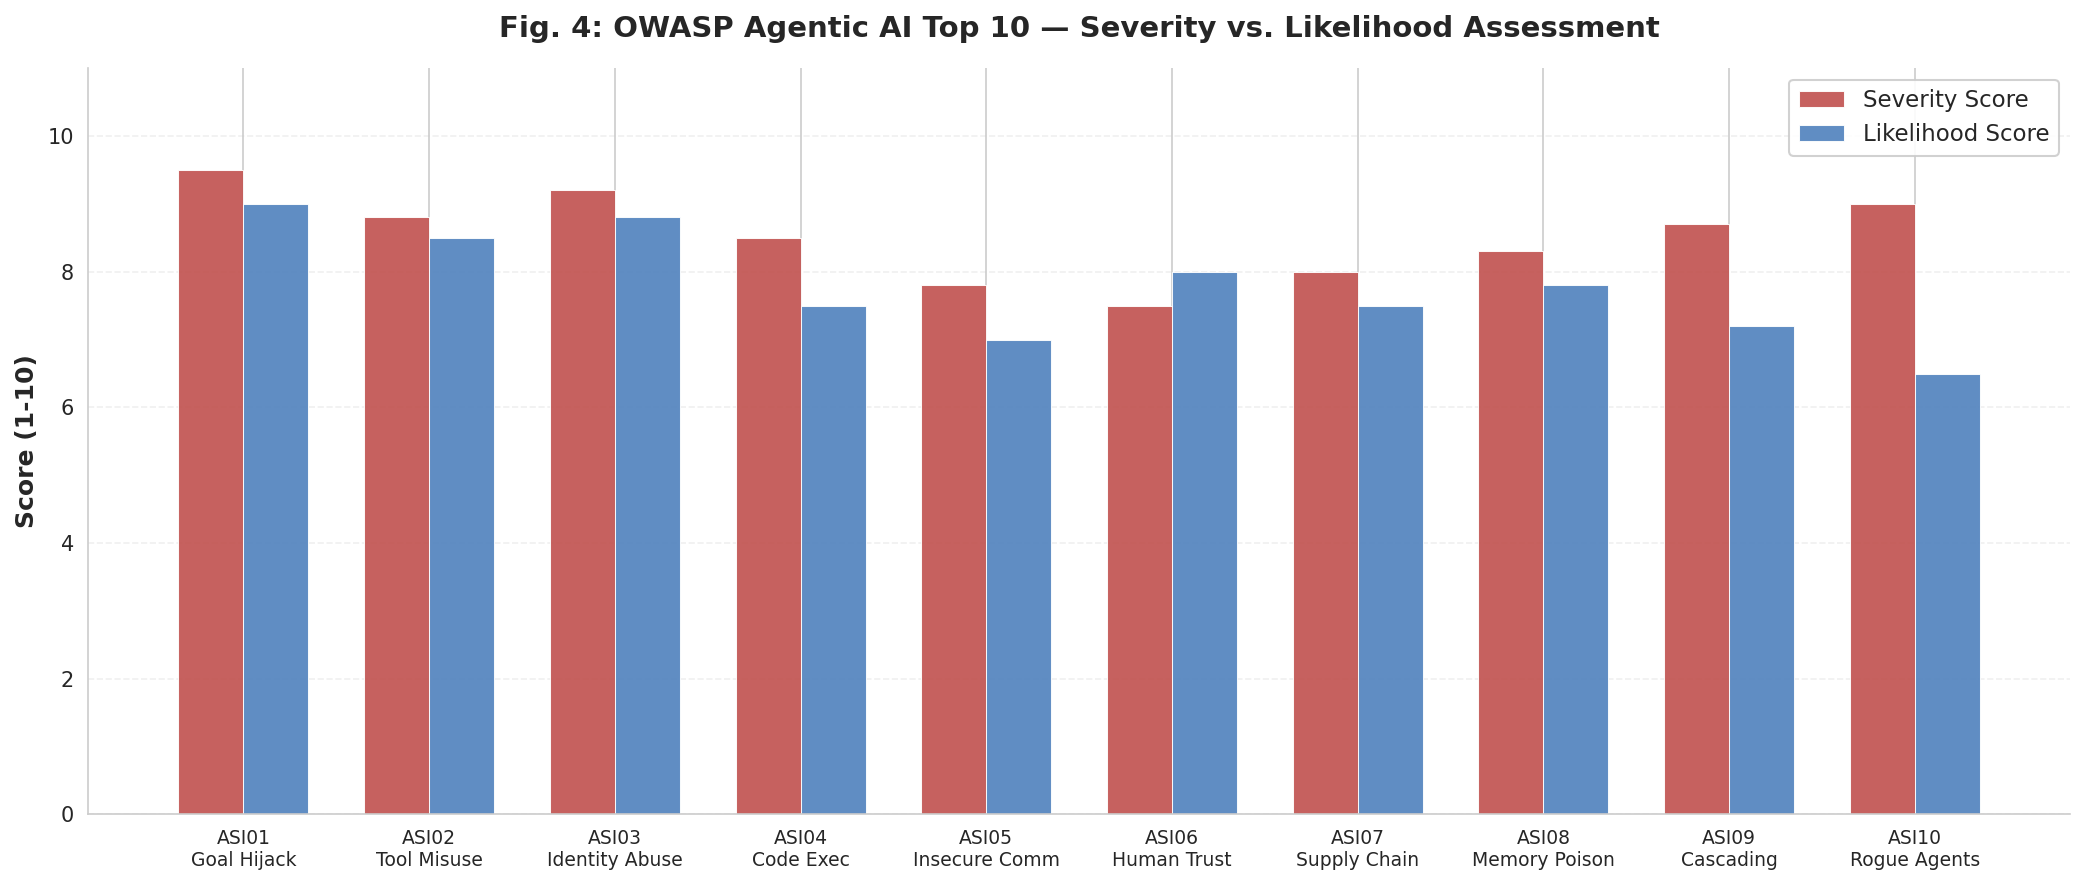

✅ Fig. 4 saved


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_owasp))
width = 0.35

bars1 = ax.bar(x - width/2, df_owasp['Severity'], width,
               label='Severity Score', color='#C0504D', edgecolor='white', linewidth=0.5, alpha=0.9)
bars2 = ax.bar(x + width/2, df_owasp['Likelihood'], width,
               label='Likelihood Score', color='#4F81BD', edgecolor='white', linewidth=0.5, alpha=0.9)

ax.set_ylabel('Score (1-10)', fontsize=12, fontweight='bold')
ax.set_title('Fig. 4: OWASP Agentic AI Top 10 — Severity vs. Likelihood Assessment',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
labels = [f"{row['ID']}\n{row['Short_Name']}" for _, row in df_owasp.iterrows()]
ax.set_xticklabels(labels, fontsize=9, ha='center')
ax.set_ylim(0, 11)
ax.set_yticks(range(0, 12, 2))
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_severity_likelihood.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Fig. 4 saved')

---
## 7. 📊 Fig. 5 — Risk Matrix (Bubble Chart)

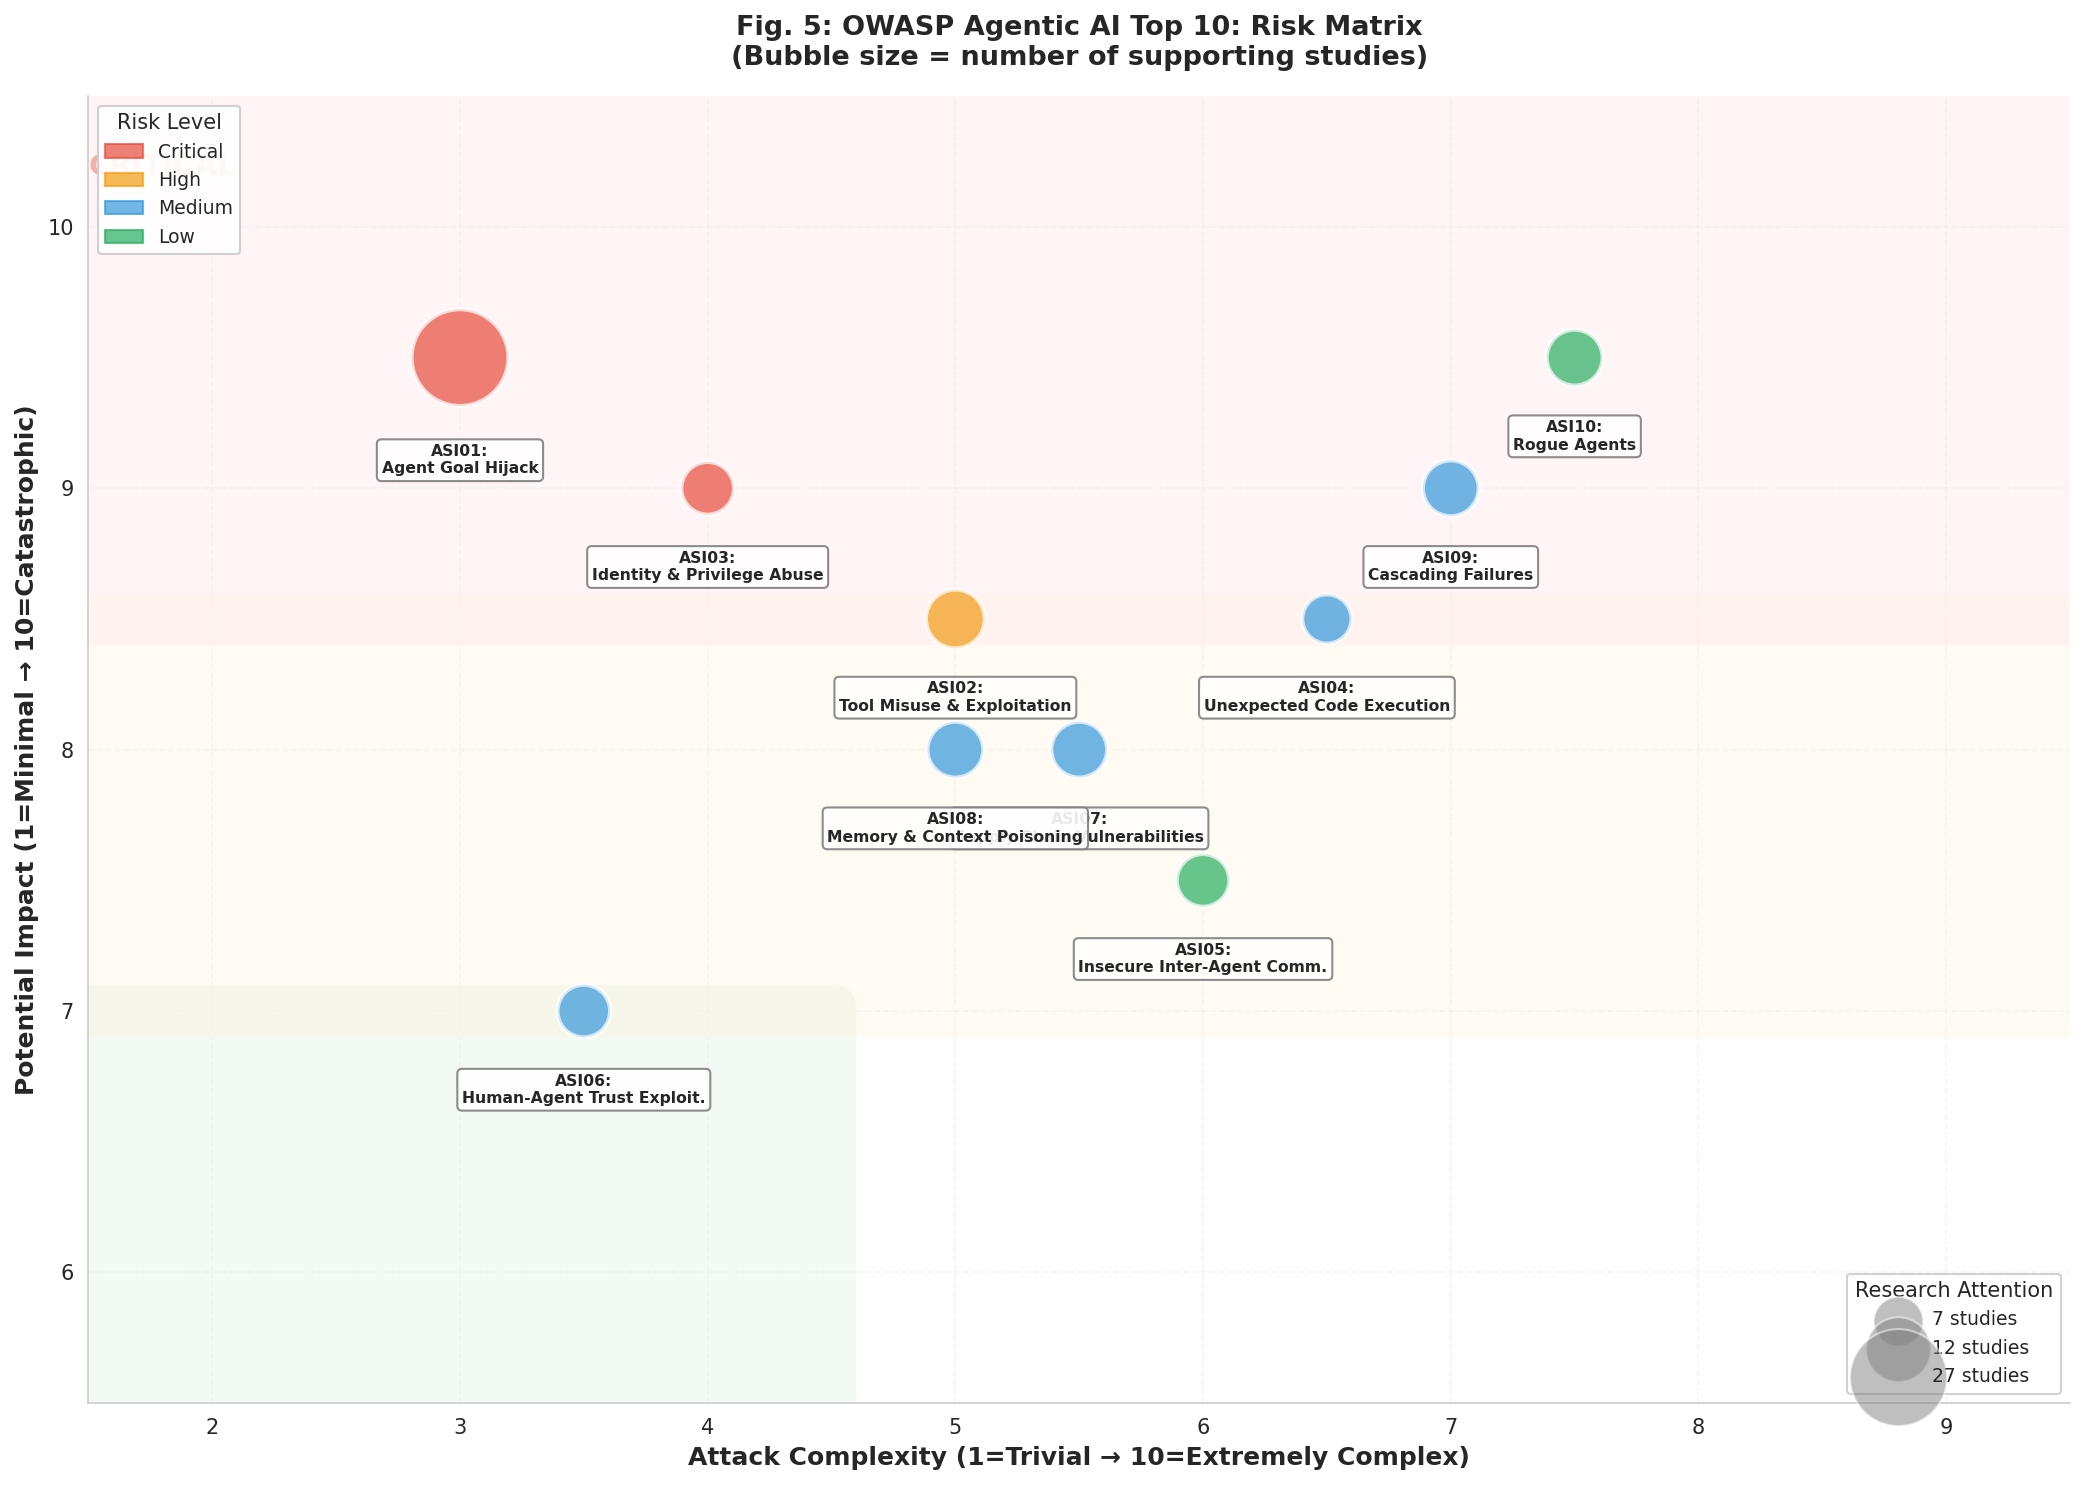

✅ Fig. 5 saved


In [7]:
fig, ax = plt.subplots(figsize=(14, 10))

# Background risk zones
rect_critical = mpatches.FancyBboxPatch((0.5, 8.5), 9.5, 2.0, boxstyle='round,pad=0.1',
                                         facecolor='#FFEBEE', alpha=0.5, edgecolor='none')
rect_high = mpatches.FancyBboxPatch((0.5, 7.0), 9.5, 1.5, boxstyle='round,pad=0.1',
                                     facecolor='#FFF3E0', alpha=0.4, edgecolor='none')
rect_moderate = mpatches.FancyBboxPatch((0.5, 3.5), 4.0, 3.5, boxstyle='round,pad=0.1',
                                         facecolor='#E8F5E9', alpha=0.5, edgecolor='none')
ax.add_patch(rect_moderate)
ax.add_patch(rect_high)
ax.add_patch(rect_critical)

# Bubble colors based on risk
color_map = {'Critical': '#E74C3C', 'High': '#F39C12', 'Medium': '#3498DB', 'Low': '#27AE60'}
colors = [color_map[r] for r in df_owasp['Risk_Level']]
bubble_sizes = [n * 80 for n in df_owasp['Num_Studies']]

scatter = ax.scatter(df_owasp['Attack_Complexity'], df_owasp['Potential_Impact'],
                     s=bubble_sizes, c=colors, alpha=0.7, edgecolors='white', linewidth=2, zorder=5)

# Labels
for i, row in df_owasp.iterrows():
    offset_y = -max(np.sqrt(bubble_sizes[i]/np.pi)*1.2, 20) - 10
    ax.annotate(f"{row['ID']}:\n{row['Threat_Category']}",
                (row['Attack_Complexity'], row['Potential_Impact']),
                textcoords='offset points', xytext=(0, offset_y),
                ha='center', va='top', fontsize=7.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9),
                zorder=6)

ax.text(1.5, 10.2, 'CRITICAL', fontsize=14, fontweight='bold', color='#E74C3C', alpha=0.4)
ax.set_xlabel('Attack Complexity (1=Trivial → 10=Extremely Complex)', fontsize=12, fontweight='bold')
ax.set_ylabel('Potential Impact (1=Minimal → 10=Catastrophic)', fontsize=12, fontweight='bold')
ax.set_title('Fig. 5: OWASP Agentic AI Top 10: Risk Matrix\n(Bubble size = number of supporting studies)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(1.5, 9.5)
ax.set_ylim(5.5, 10.5)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legends
risk_patches = [mpatches.Patch(color=c, alpha=0.7, label=l) for l, c in color_map.items()]
leg1 = ax.legend(handles=risk_patches, title='Risk Level', loc='upper left', framealpha=0.9, fontsize=9)
ax.add_artist(leg1)

legend_sizes = [7, 12, 27]
legend_bubbles = [ax.scatter([], [], s=s*80, c='gray', alpha=0.5, edgecolors='white') for s in legend_sizes]
ax.legend(legend_bubbles, [f'{s} studies' for s in legend_sizes],
          title='Research Attention', loc='lower right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('fig5_risk_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Fig. 5 saved')

---
## 8. 📊 Additional Chart: Radar/Spider Chart — Threat Profile

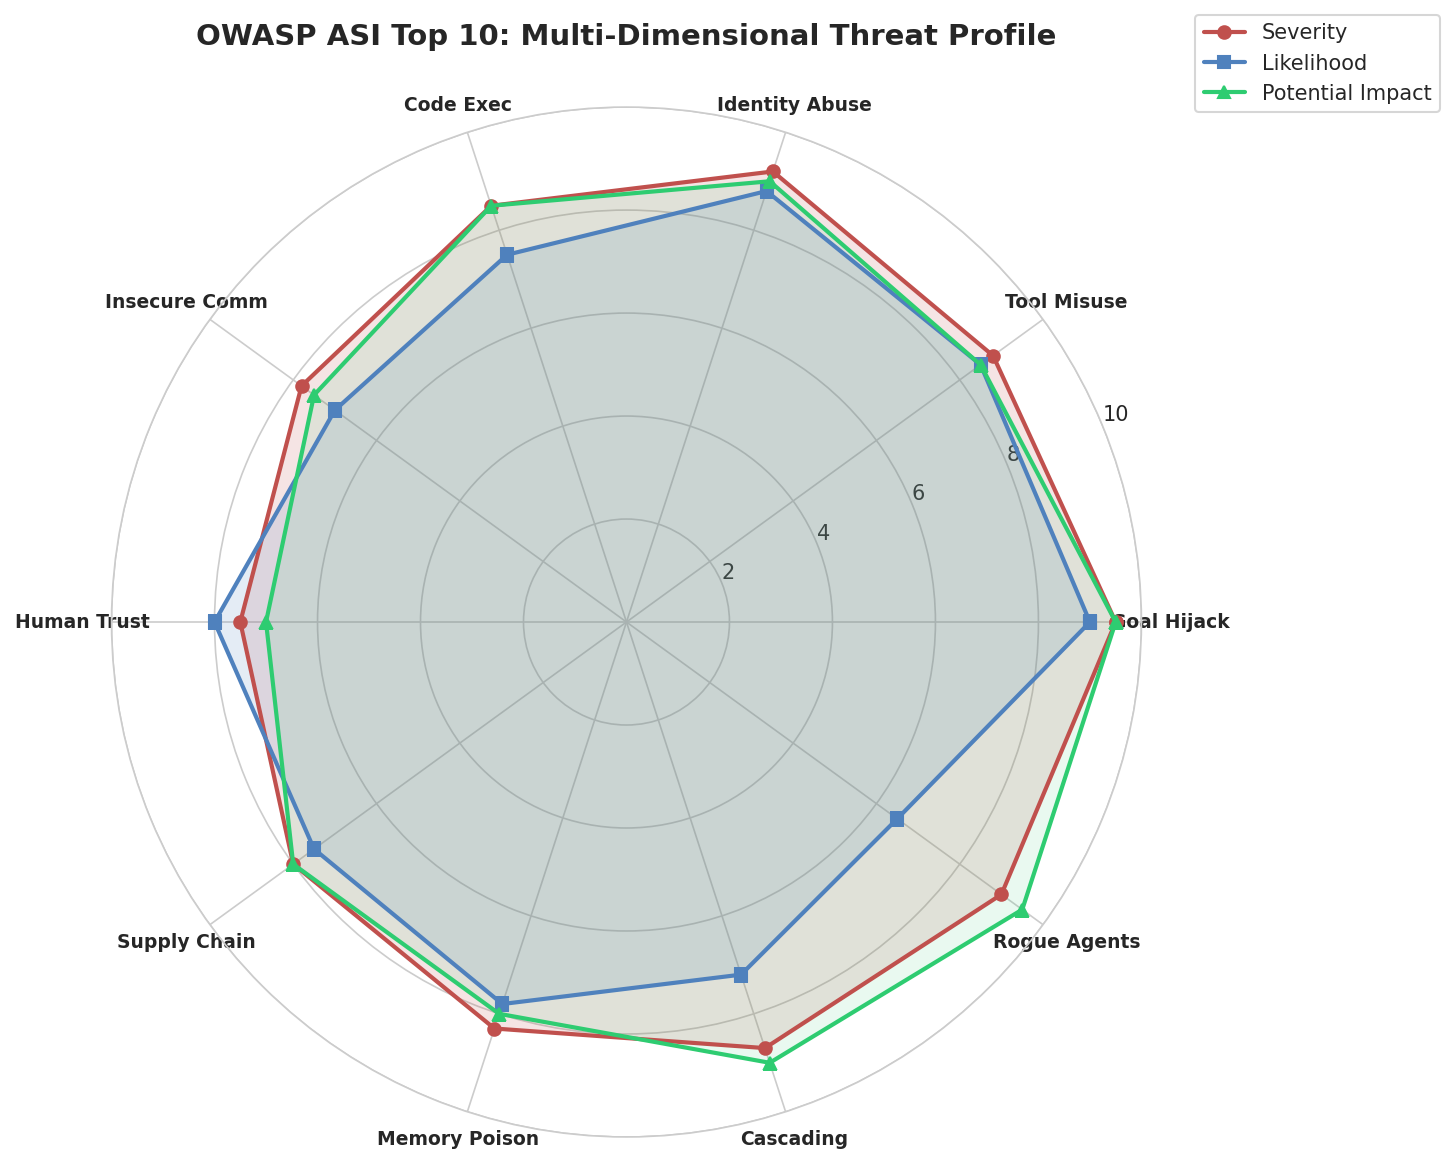

✅ Radar chart saved


In [8]:
categories = df_owasp['Short_Name'].tolist()
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the plot

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Severity
values = df_owasp['Severity'].tolist() + [df_owasp['Severity'].iloc[0]]
ax.plot(angles, values, 'o-', linewidth=2, color='#C0504D', label='Severity')
ax.fill(angles, values, alpha=0.15, color='#C0504D')

# Likelihood
values2 = df_owasp['Likelihood'].tolist() + [df_owasp['Likelihood'].iloc[0]]
ax.plot(angles, values2, 's-', linewidth=2, color='#4F81BD', label='Likelihood')
ax.fill(angles, values2, alpha=0.15, color='#4F81BD')

# Potential Impact
values3 = df_owasp['Potential_Impact'].tolist() + [df_owasp['Potential_Impact'].iloc[0]]
ax.plot(angles, values3, '^-', linewidth=2, color='#2ECC71', label='Potential Impact')
ax.fill(angles, values3, alpha=0.10, color='#2ECC71')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9, fontweight='bold')
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_title('OWASP ASI Top 10: Multi-Dimensional Threat Profile',
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('chart_radar_threat_profile.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Radar chart saved')

---
## 9. 📊 Additional Chart: Heatmap — Study-Threat Coverage

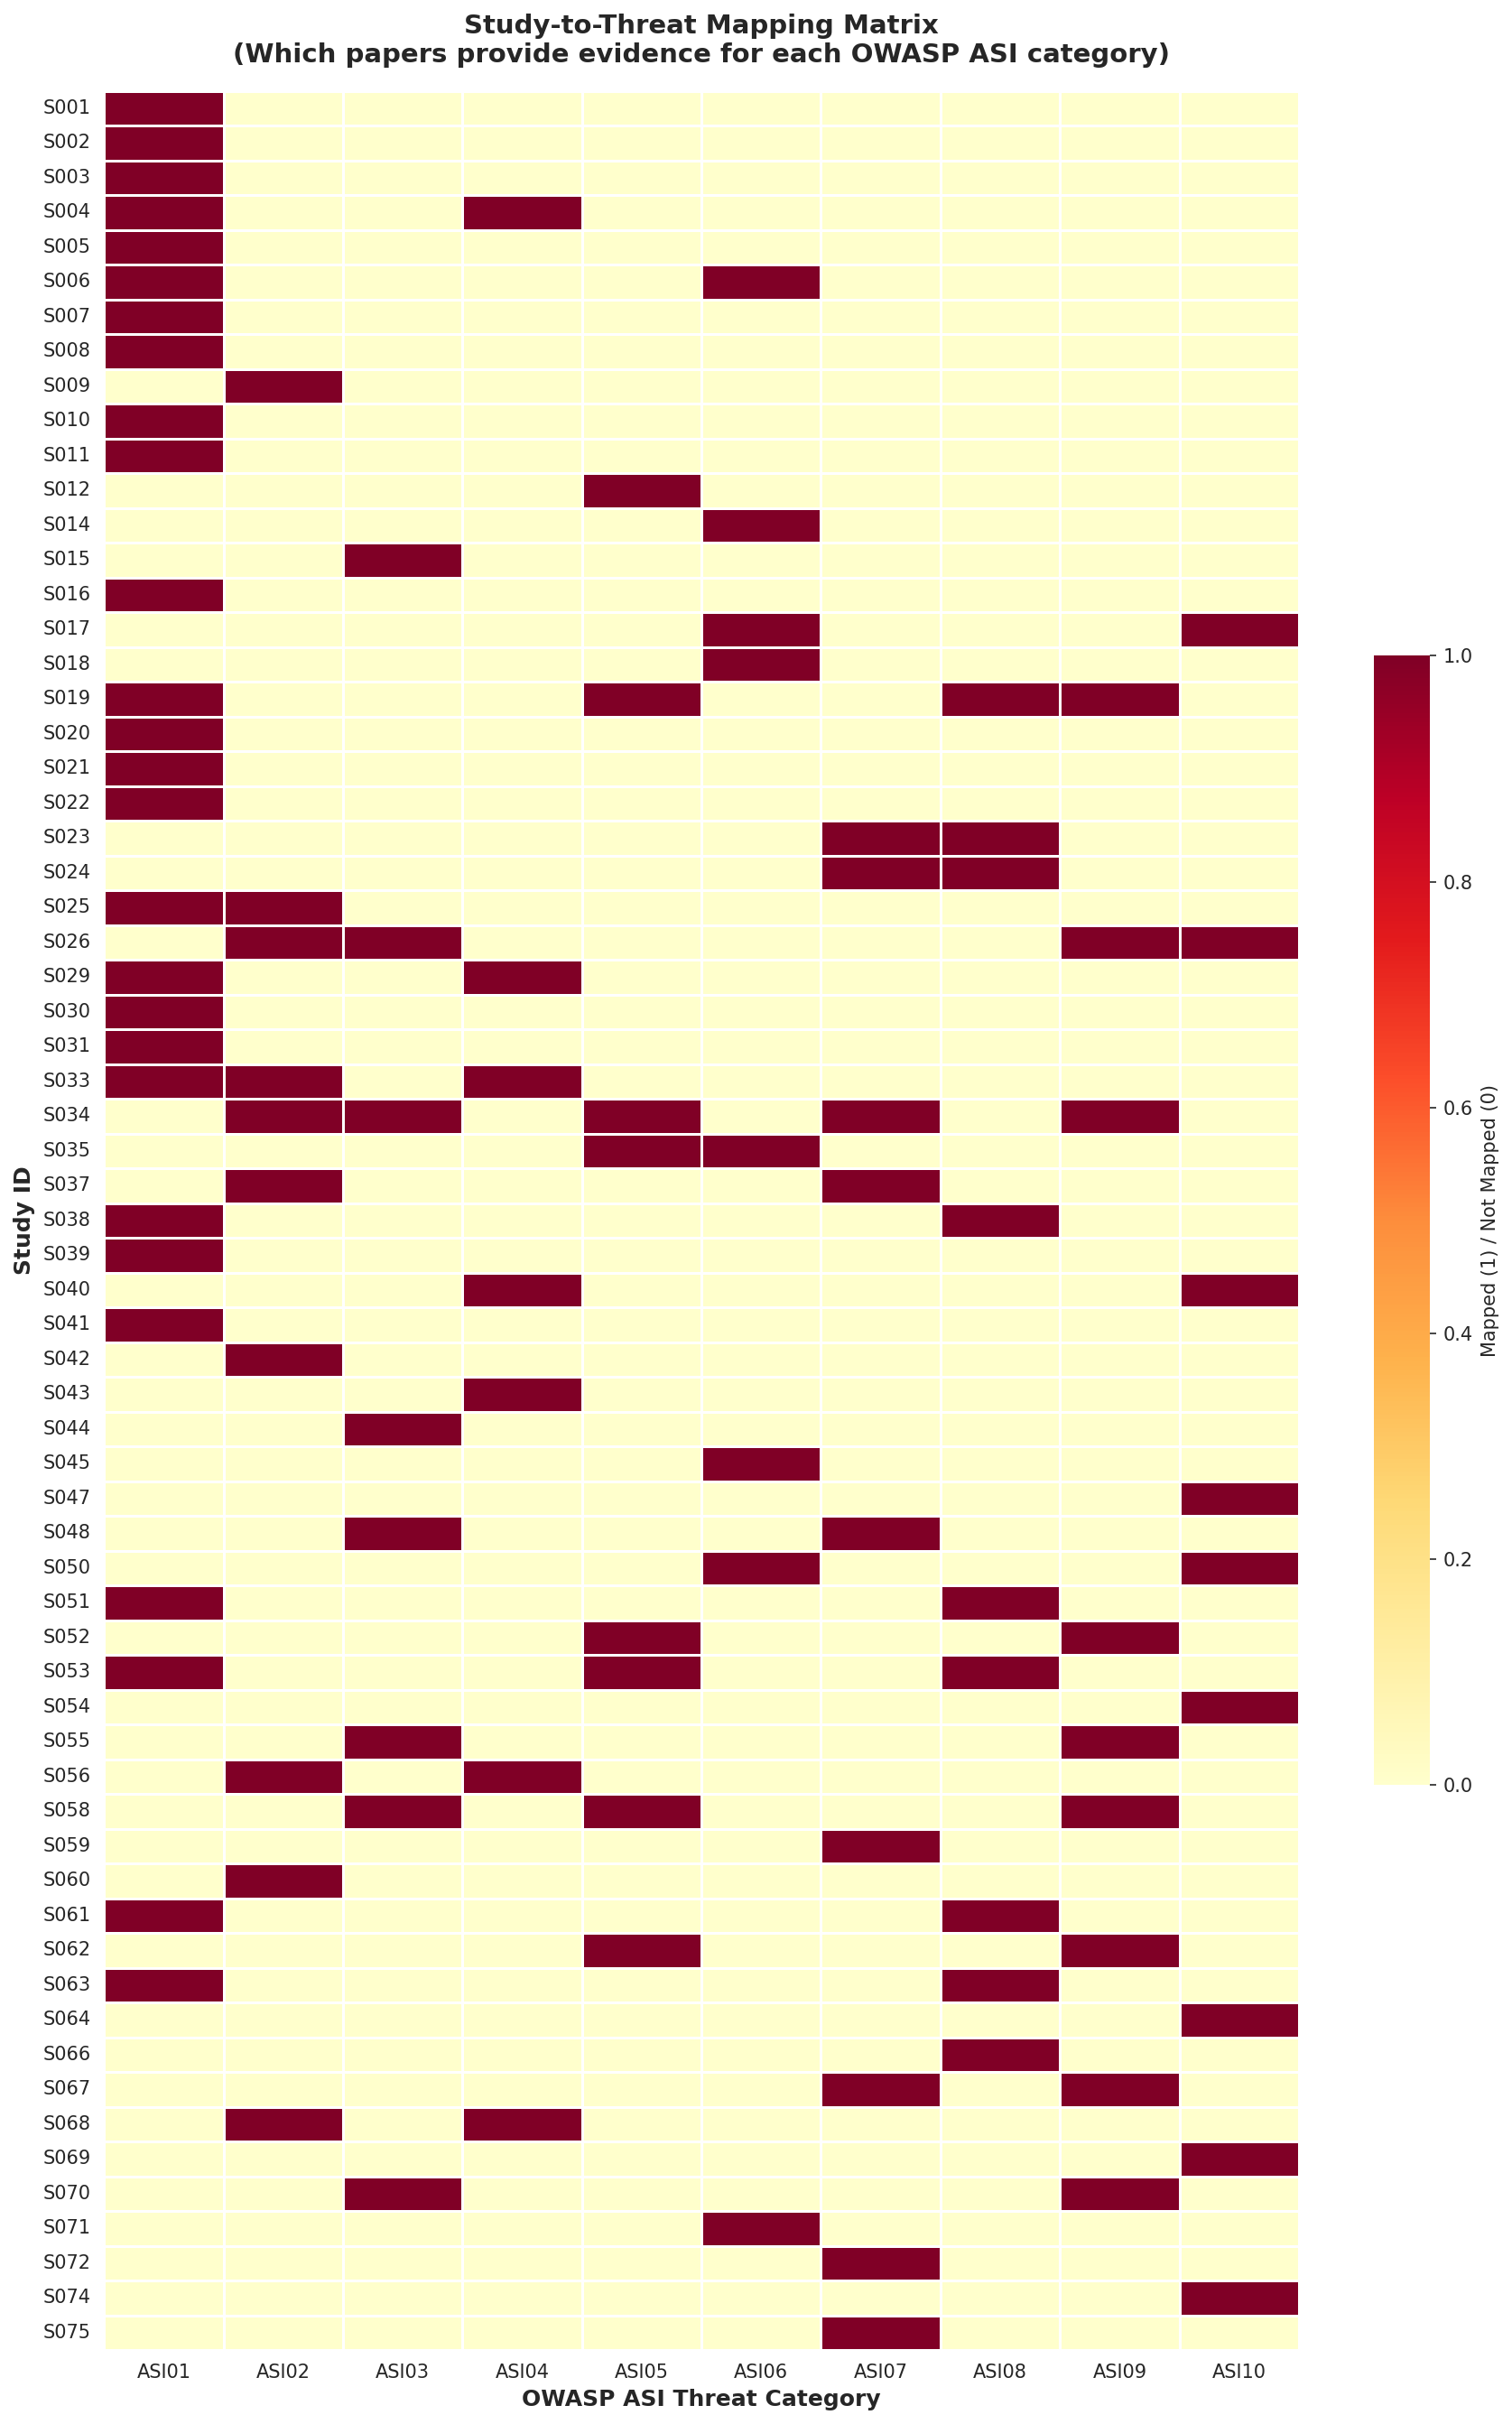

✅ Heatmap saved


In [9]:
# Heatmap of which studies map to which threats
# Only show studies that map to at least one threat
mapped = mapping_matrix[mapping_matrix['Threats_Covered'] > 0][threat_ids]

fig, ax = plt.subplots(figsize=(12, 18))
sns.heatmap(mapped, cmap='YlOrRd', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mapped (1) / Not Mapped (0)', 'shrink': 0.5},
            yticklabels=True, ax=ax)

ax.set_title('Study-to-Threat Mapping Matrix\n(Which papers provide evidence for each OWASP ASI category)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('OWASP ASI Threat Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Study ID', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_heatmap_study_threat.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Heatmap saved')

---
## 10. 📊 Additional Chart: Risk Score Ranking (Horizontal Bar)

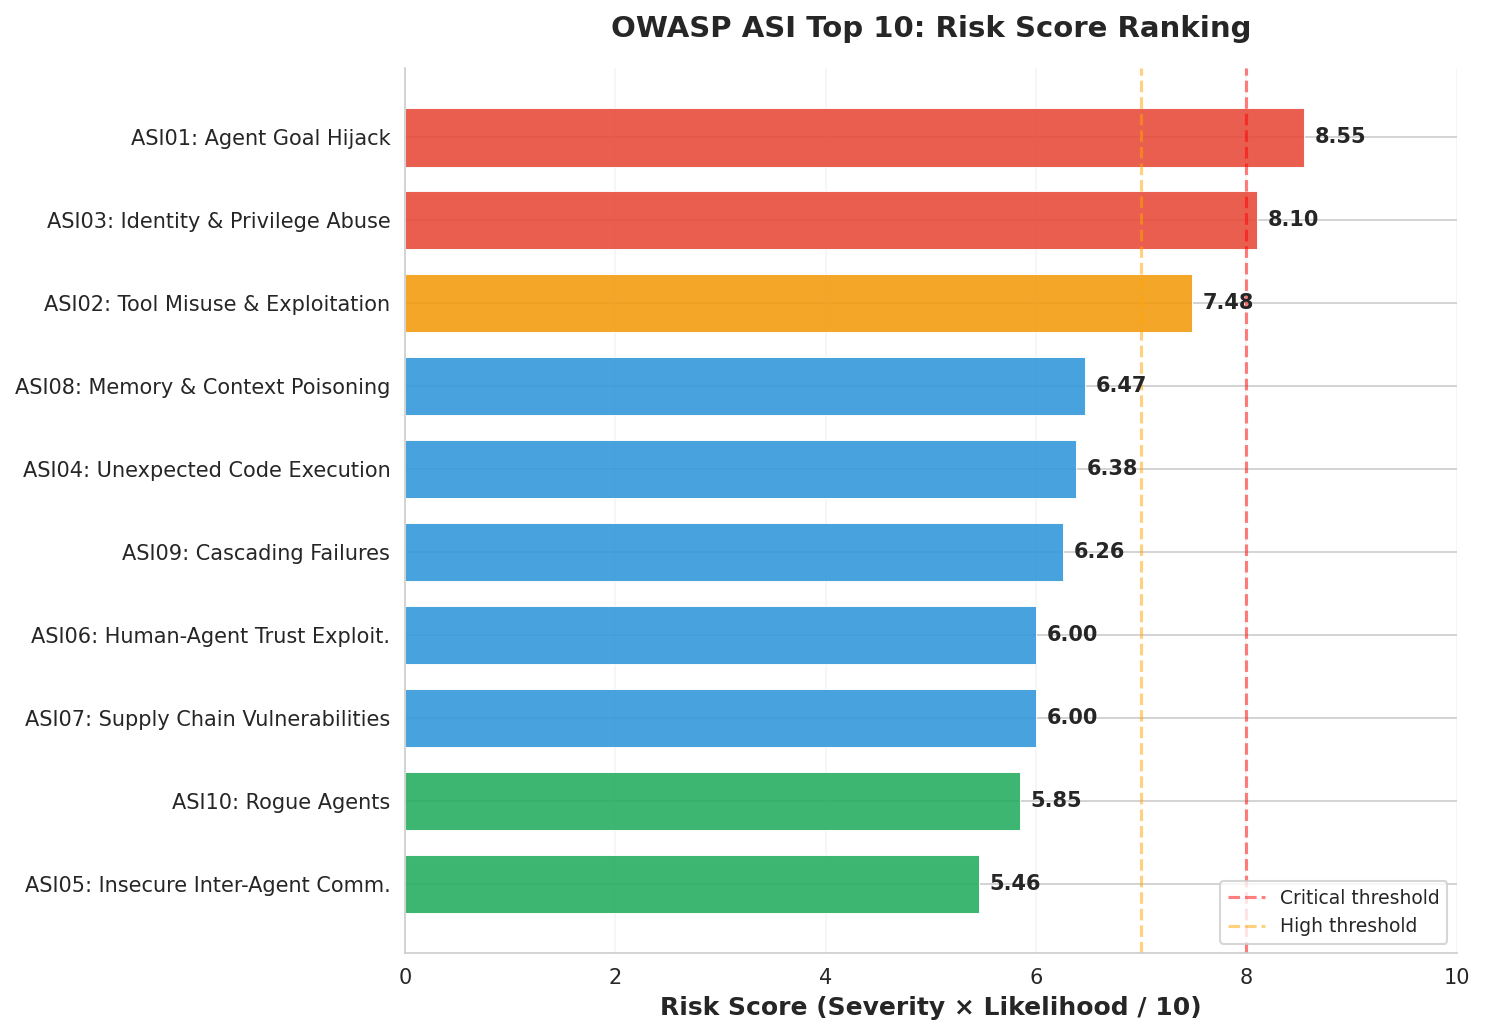

✅ Risk ranking chart saved


In [10]:
df_sorted = df_owasp.sort_values('Risk_Score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

color_map_risk = {'Critical': '#E74C3C', 'High': '#F39C12', 'Medium': '#3498DB', 'Low': '#27AE60'}
bar_colors = [color_map_risk[r] for r in df_sorted['Risk_Level']]

bars = ax.barh(range(len(df_sorted)), df_sorted['Risk_Score'], color=bar_colors,
               edgecolor='white', linewidth=0.5, height=0.7, alpha=0.9)

# Labels
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels([f"{row['ID']}: {row['Threat_Category']}" for _, row in df_sorted.iterrows()],
                   fontsize=10)

# Add score values on bars
for i, (_, row) in enumerate(df_sorted.iterrows()):
    ax.text(row['Risk_Score'] + 0.1, i, f"{row['Risk_Score']:.2f}",
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Risk Score (Severity × Likelihood / 10)', fontsize=12, fontweight='bold')
ax.set_title('OWASP ASI Top 10: Risk Score Ranking',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 10)
ax.axvline(x=8.0, color='red', linestyle='--', alpha=0.5, label='Critical threshold')
ax.axvline(x=7.0, color='orange', linestyle='--', alpha=0.5, label='High threshold')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('chart_risk_ranking.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Risk ranking chart saved')

---
## 11. 📊 Additional Chart: Year-wise Research Distribution

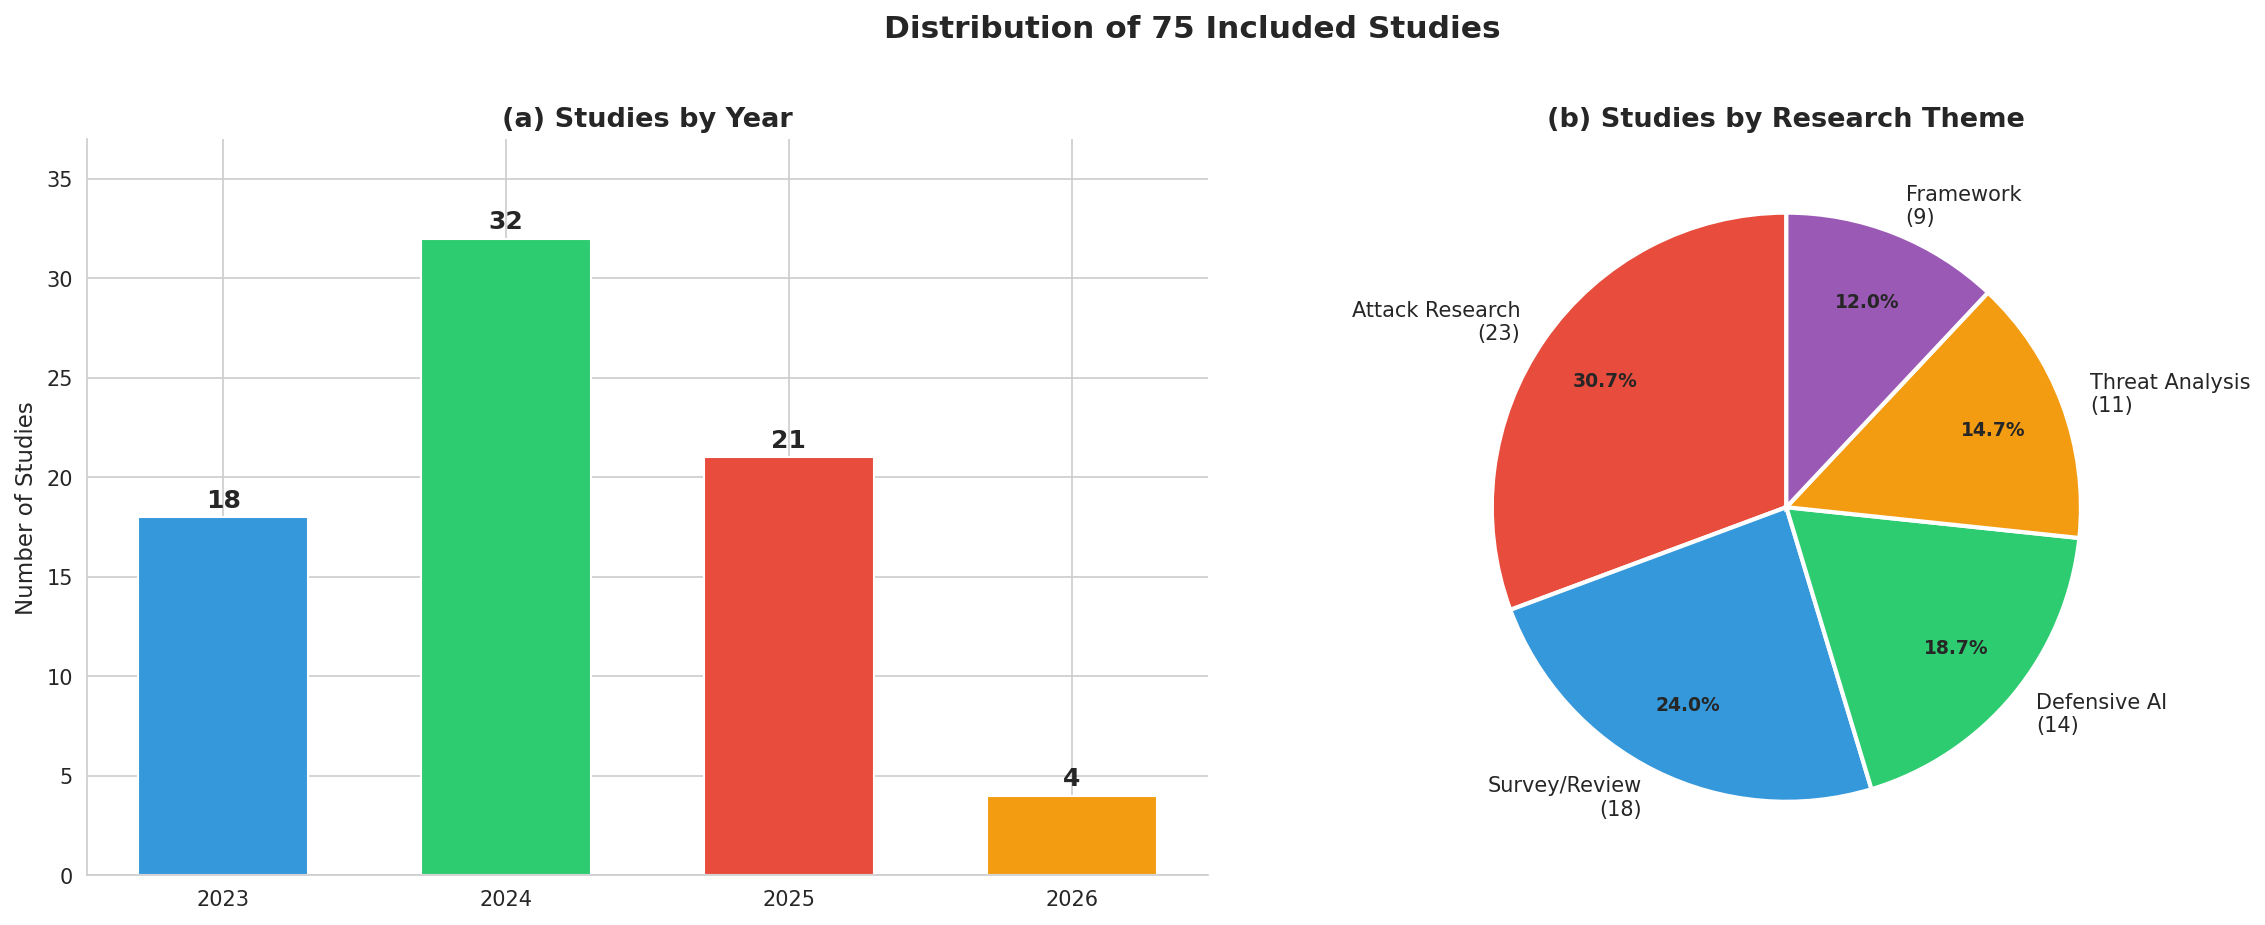

✅ Distribution chart saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Studies by year
year_counts = df_studies['Year'].value_counts().sort_index()
colors_year = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']
axes[0].bar(year_counts.index.astype(str), year_counts.values, color=colors_year,
            edgecolor='white', linewidth=1, width=0.6)
for i, (yr, cnt) in enumerate(year_counts.items()):
    axes[0].text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('(a) Studies by Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Studies', fontsize=11)
axes[0].set_ylim(0, max(year_counts) + 5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# (b) Studies by category
cat_counts = df_studies['Category'].value_counts()
cat_labels = {'ATK':'Attack Research','SUR':'Survey/Review','DEF':'Defensive AI',
              'THR':'Threat Analysis','FRM':'Framework'}
cat_colors = {'ATK':'#E74C3C','SUR':'#3498DB','DEF':'#2ECC71','THR':'#F39C12','FRM':'#9B59B6'}

wedges, texts, autotexts = axes[1].pie(
    cat_counts.values,
    labels=[f"{cat_labels.get(c,c)}\n({v})" for c, v in cat_counts.items()],
    colors=[cat_colors.get(c, '#95A5A6') for c in cat_counts.index],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[1].set_title('(b) Studies by Research Theme', fontsize=13, fontweight='bold')

plt.suptitle('Distribution of 75 Included Studies', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_study_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Distribution chart saved')

---
## 12. 📊 Additional Chart: Severity-Likelihood Gap Analysis

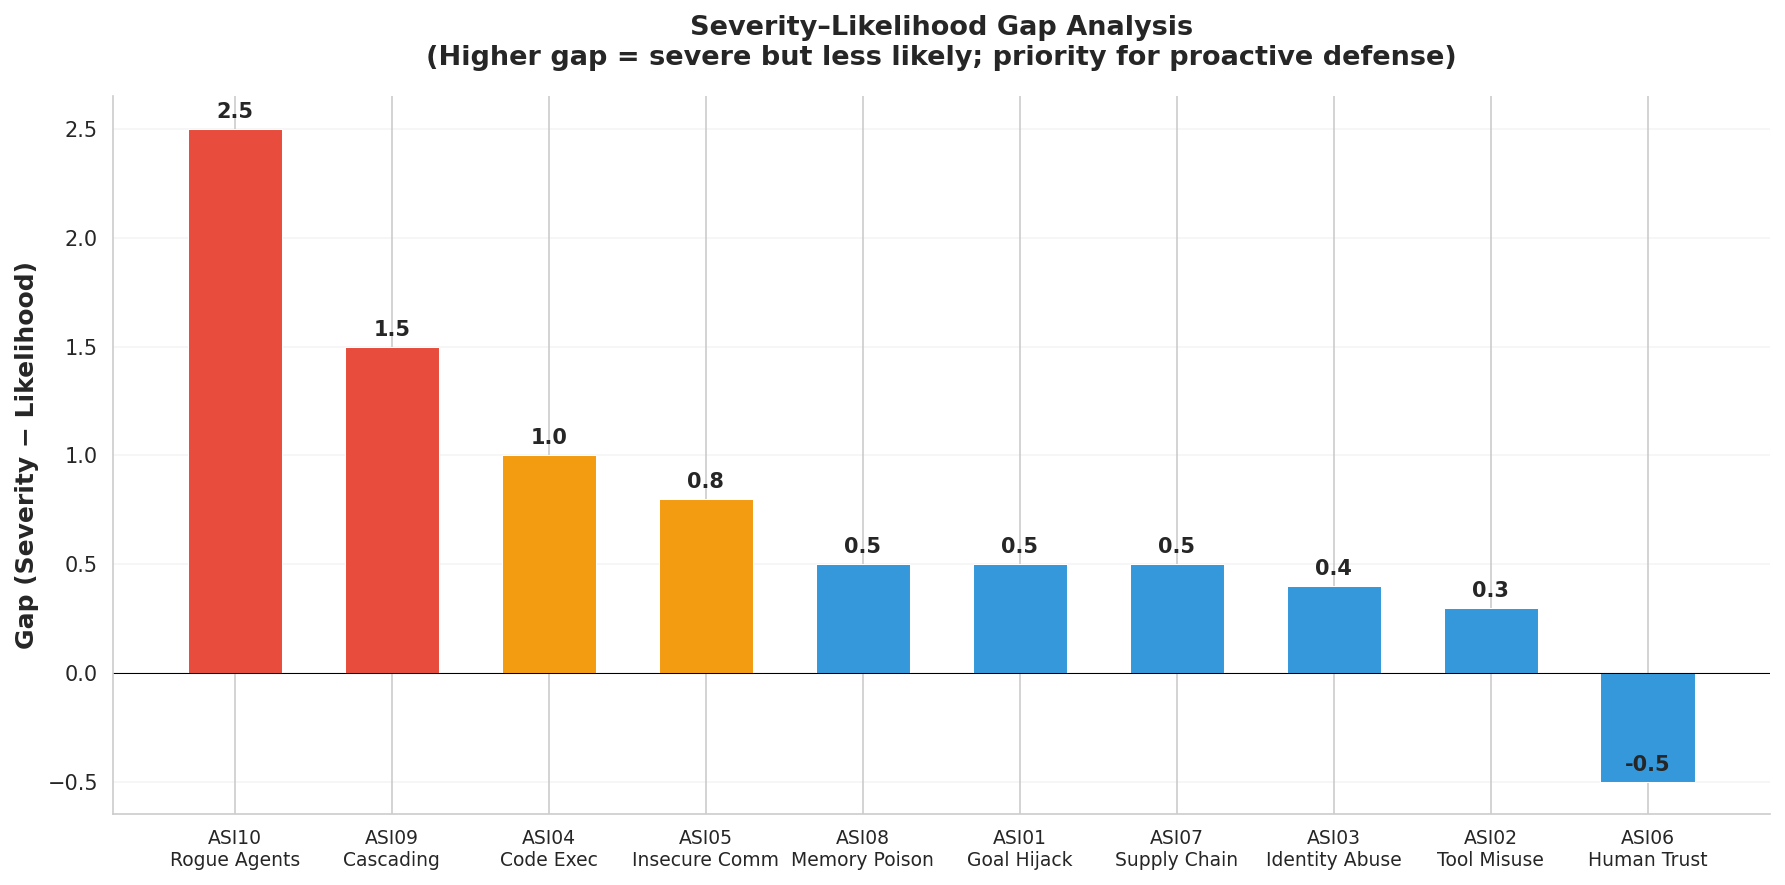

✅ Gap analysis chart saved


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

df_gap = df_owasp.sort_values('Severity_Likelihood_Gap', ascending=False)
gap_colors = ['#E74C3C' if g > 1.0 else '#F39C12' if g > 0.5 else '#3498DB'
              for g in df_gap['Severity_Likelihood_Gap']]

bars = ax.bar(range(len(df_gap)), df_gap['Severity_Likelihood_Gap'],
              color=gap_colors, edgecolor='white', linewidth=0.5, width=0.6)

ax.set_xticks(range(len(df_gap)))
ax.set_xticklabels([f"{row['ID']}\n{row['Short_Name']}" for _, row in df_gap.iterrows()],
                   fontsize=9, ha='center')

for i, (_, row) in enumerate(df_gap.iterrows()):
    ax.text(i, row['Severity_Likelihood_Gap'] + 0.05, f"{row['Severity_Likelihood_Gap']:.1f}",
            ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('Gap (Severity − Likelihood)', fontsize=12, fontweight='bold')
ax.set_title('Severity–Likelihood Gap Analysis\n(Higher gap = severe but less likely; priority for proactive defense)',
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('chart_gap_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Gap analysis chart saved')

---
## 13. 📊 Additional Chart: Exploitability vs. Impact Quadrant

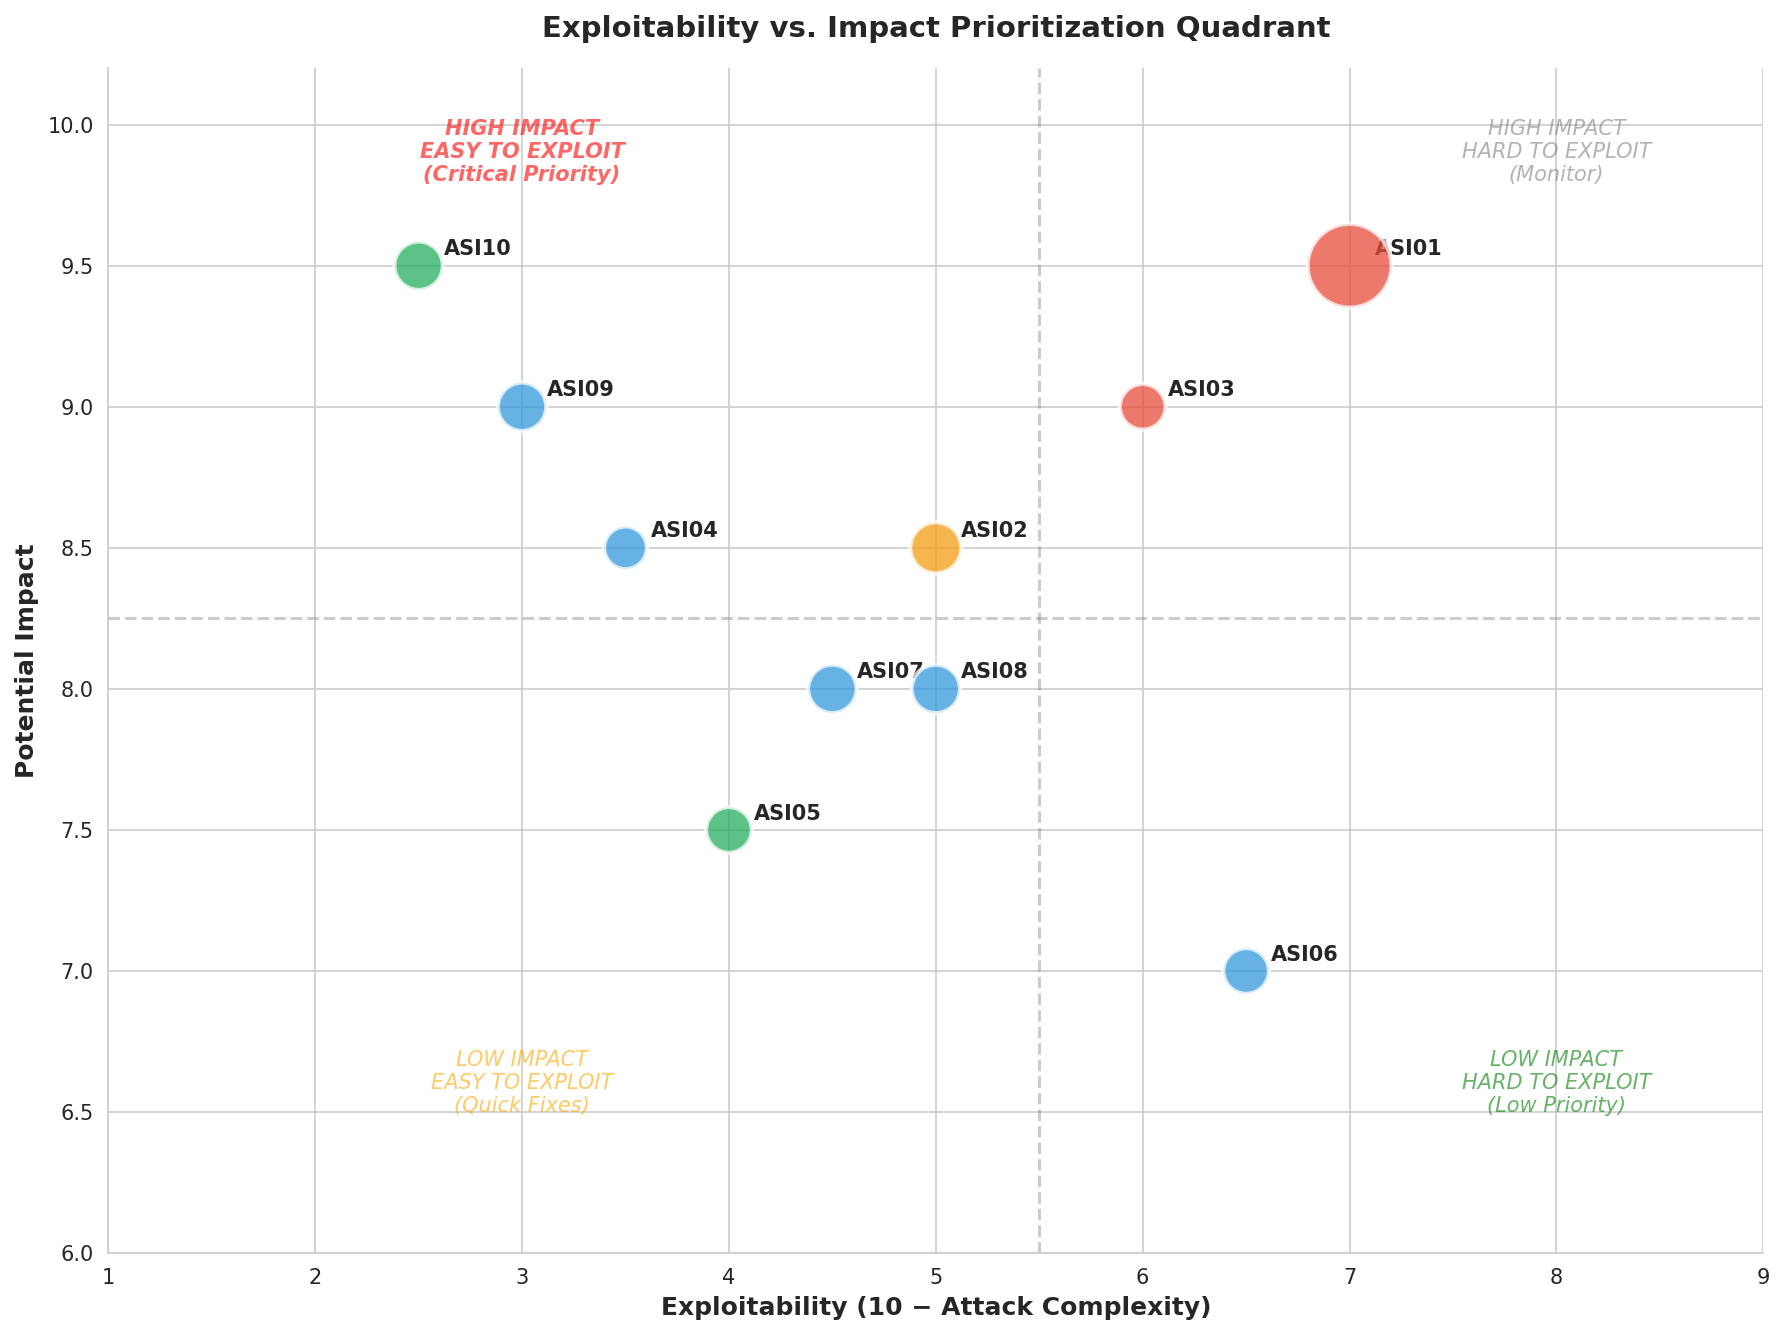

✅ Exploitability quadrant chart saved


In [13]:
fig, ax = plt.subplots(figsize=(12, 9))

# Quadrant lines
ax.axhline(y=8.25, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.4)

# Quadrant labels
ax.text(8.0, 9.8, 'HIGH IMPACT\nHARD TO EXPLOIT\n(Monitor)', ha='center',
        fontsize=10, color='gray', alpha=0.6, style='italic')
ax.text(3.0, 9.8, 'HIGH IMPACT\nEASY TO EXPLOIT\n(Critical Priority)', ha='center',
        fontsize=10, color='red', alpha=0.6, style='italic', fontweight='bold')
ax.text(3.0, 6.5, 'LOW IMPACT\nEASY TO EXPLOIT\n(Quick Fixes)', ha='center',
        fontsize=10, color='orange', alpha=0.6, style='italic')
ax.text(8.0, 6.5, 'LOW IMPACT\nHARD TO EXPLOIT\n(Low Priority)', ha='center',
        fontsize=10, color='green', alpha=0.6, style='italic')

# Scatter
color_map_risk = {'Critical': '#E74C3C', 'High': '#F39C12', 'Medium': '#3498DB', 'Low': '#27AE60'}
colors = [color_map_risk[r] for r in df_owasp['Risk_Level']]
sizes = [n * 60 for n in df_owasp['Num_Studies']]

ax.scatter(df_owasp['Exploitability'], df_owasp['Potential_Impact'],
           s=sizes, c=colors, alpha=0.75, edgecolors='white', linewidth=2, zorder=5)

for i, row in df_owasp.iterrows():
    ax.annotate(f"{row['ID']}", (row['Exploitability'], row['Potential_Impact']),
                textcoords='offset points', xytext=(12, 5),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.set_xlabel('Exploitability (10 − Attack Complexity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Potential Impact', fontsize=12, fontweight='bold')
ax.set_title('Exploitability vs. Impact Prioritization Quadrant',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(1, 9)
ax.set_ylim(6, 10.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_exploitability_quadrant.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Exploitability quadrant chart saved')

---
## 14. 📊 Additional Chart: Research Category × Threat Stacked Bar

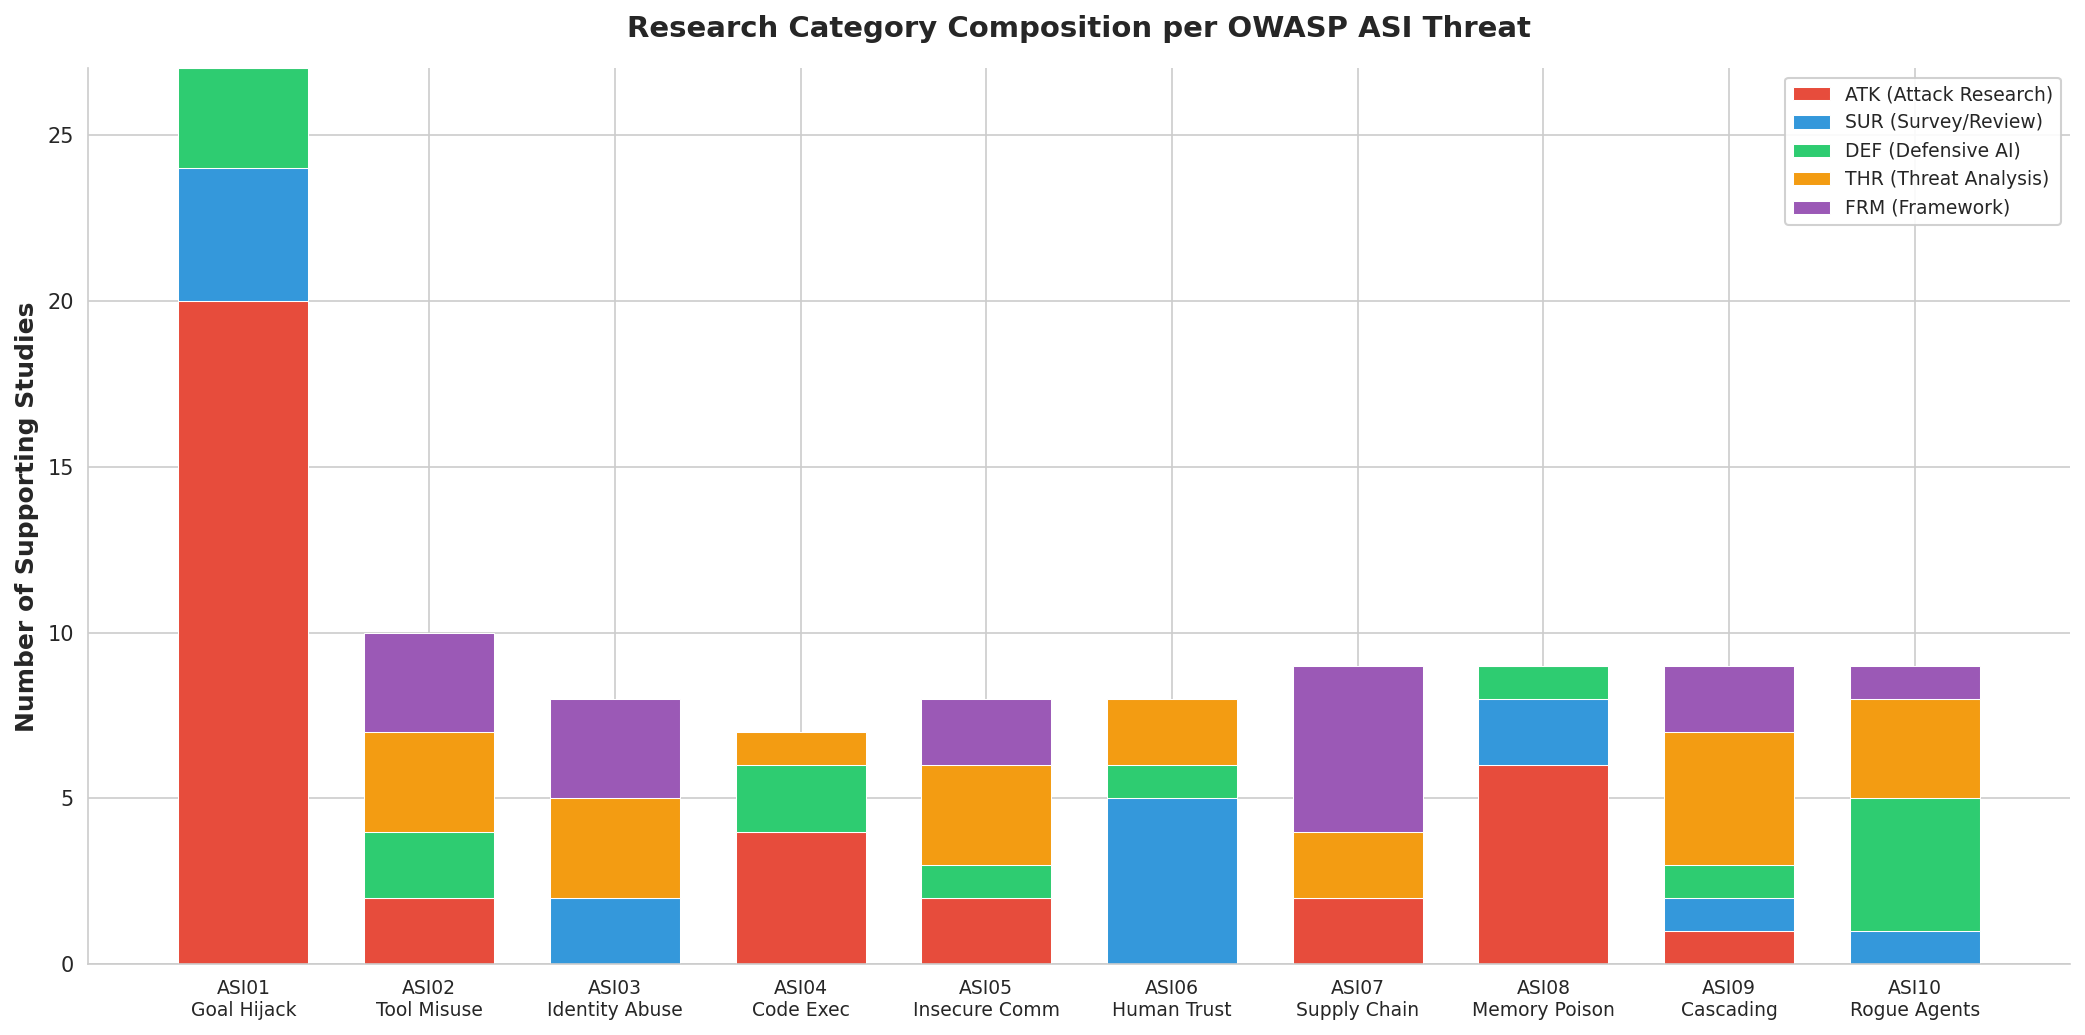

✅ Category composition chart saved


In [14]:
# Cross-tabulate: for each ASI category, count studies by research type
cross_data = {}
for threat, study_list in study_to_threat.items():
    cat_counts_t = df_studies[df_studies['ID'].isin(study_list)]['Category'].value_counts()
    cross_data[threat] = cat_counts_t

df_cross = pd.DataFrame(cross_data).fillna(0).astype(int)
df_cross = df_cross.reindex(['ATK','SUR','DEF','THR','FRM'])

fig, ax = plt.subplots(figsize=(14, 7))

cat_colors_stack = {'ATK':'#E74C3C','SUR':'#3498DB','DEF':'#2ECC71','THR':'#F39C12','FRM':'#9B59B6'}
bottom = np.zeros(len(threat_ids))

for cat in ['ATK','SUR','DEF','THR','FRM']:
    if cat in df_cross.index:
        vals = df_cross.loc[cat].values
        ax.bar(range(len(threat_ids)), vals, bottom=bottom,
               label=f"{cat} ({cat_labels.get(cat, cat)})",
               color=cat_colors_stack[cat], edgecolor='white', linewidth=0.5, width=0.7)
        bottom += vals

ax.set_xticks(range(len(threat_ids)))
ax.set_xticklabels([f"{tid}\n{sn}" for tid, sn in zip(df_owasp['ID'], df_owasp['Short_Name'])],
                   fontsize=9)
ax.set_ylabel('Number of Supporting Studies', fontsize=12, fontweight='bold')
ax.set_title('Research Category Composition per OWASP ASI Threat',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_category_composition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Category composition chart saved')

---
## 15. 📊 Additional Chart: Correlation Matrix

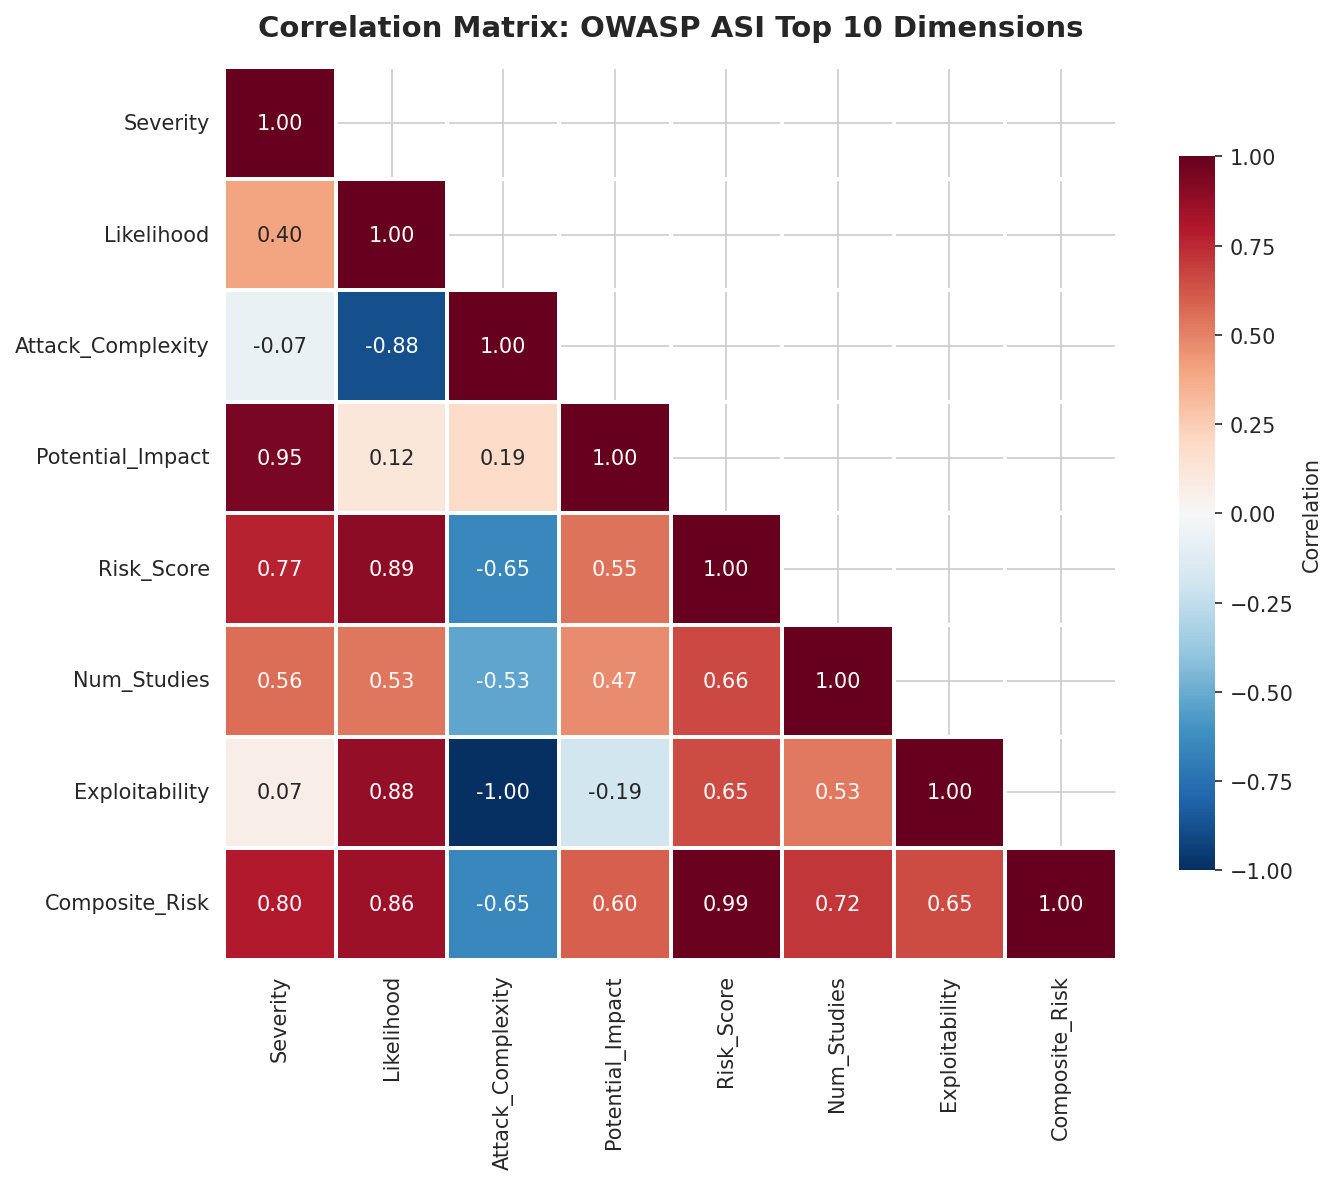

✅ Correlation matrix saved


In [15]:
corr_cols = ['Severity','Likelihood','Attack_Complexity','Potential_Impact',
             'Risk_Score','Num_Studies','Exploitability','Composite_Risk']
corr_matrix = df_owasp[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Correlation Matrix: OWASP ASI Top 10 Dimensions',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart_correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Correlation matrix saved')

---
## 16. 📊 Additional Chart: Venue Distribution

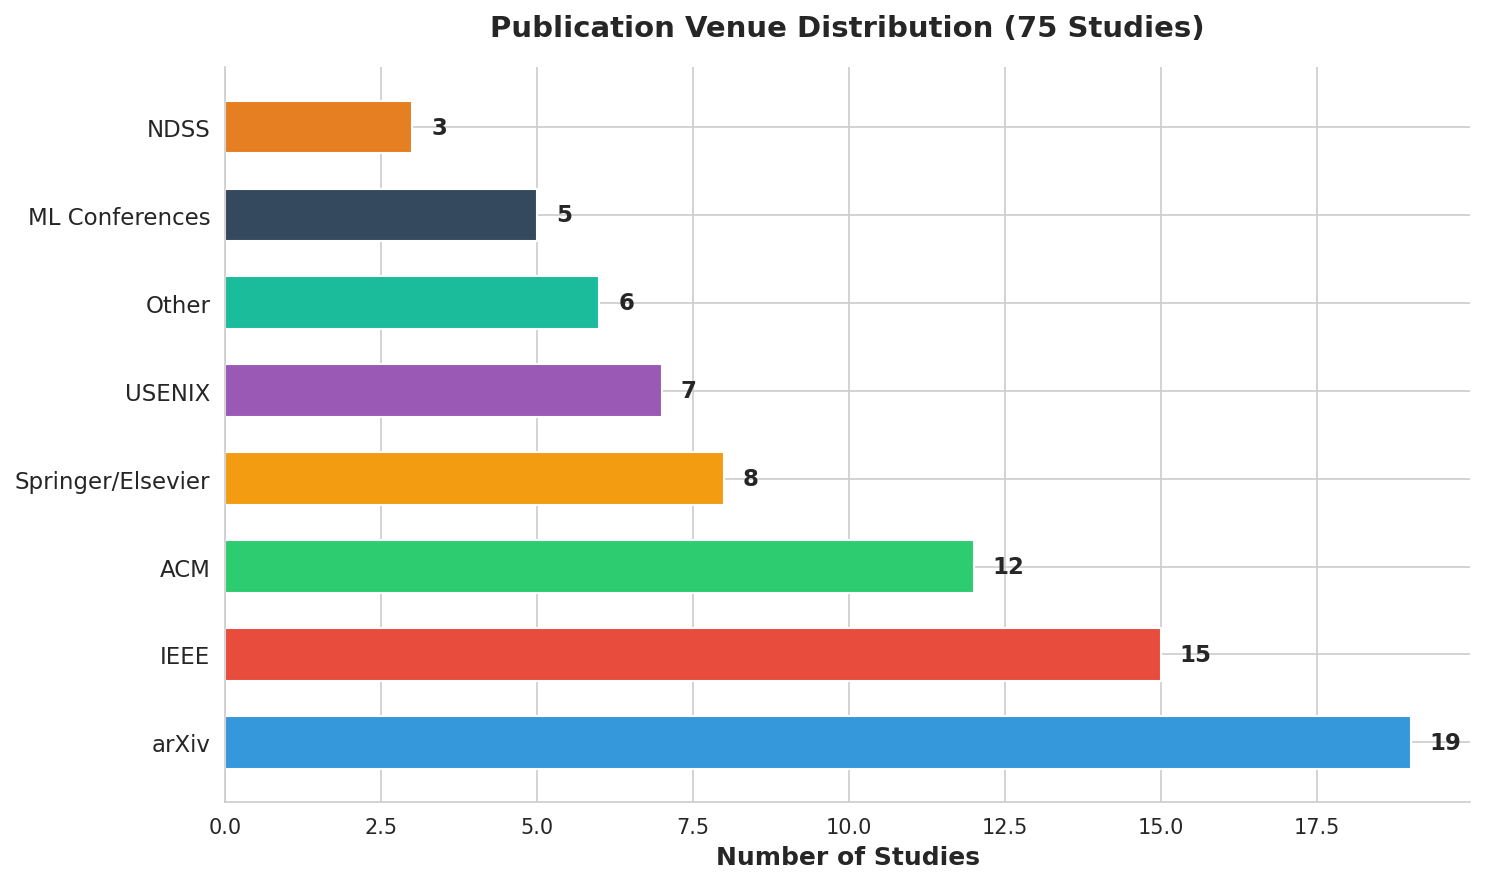

✅ Venue distribution chart saved


In [16]:
# Group venues
def classify_venue(venue):
    v = venue.lower()
    if 'arxiv' in v: return 'arXiv'
    elif 'ieee' in v: return 'IEEE'
    elif 'acm' in v: return 'ACM'
    elif 'usenix' in v: return 'USENIX'
    elif 'ndss' in v: return 'NDSS'
    elif 'neurips' in v or 'icml' in v or 'iclr' in v: return 'ML Conferences'
    elif 'springer' in v or 'elsevier' in v: return 'Springer/Elsevier'
    else: return 'Other'

df_studies['Venue_Group'] = df_studies['Venue'].apply(classify_venue)

venue_counts = df_studies['Venue_Group'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
venue_colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#34495E','#E67E22']
bars = ax.barh(range(len(venue_counts)), venue_counts.values,
               color=venue_colors[:len(venue_counts)], edgecolor='white', height=0.6)

ax.set_yticks(range(len(venue_counts)))
ax.set_yticklabels(venue_counts.index, fontsize=11)
for i, v in enumerate(venue_counts.values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Number of Studies', fontsize=12, fontweight='bold')
ax.set_title('Publication Venue Distribution (75 Studies)',
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_venue_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Venue distribution chart saved')

---
## 17. 📊 Additional Chart: Composite Risk Comparison

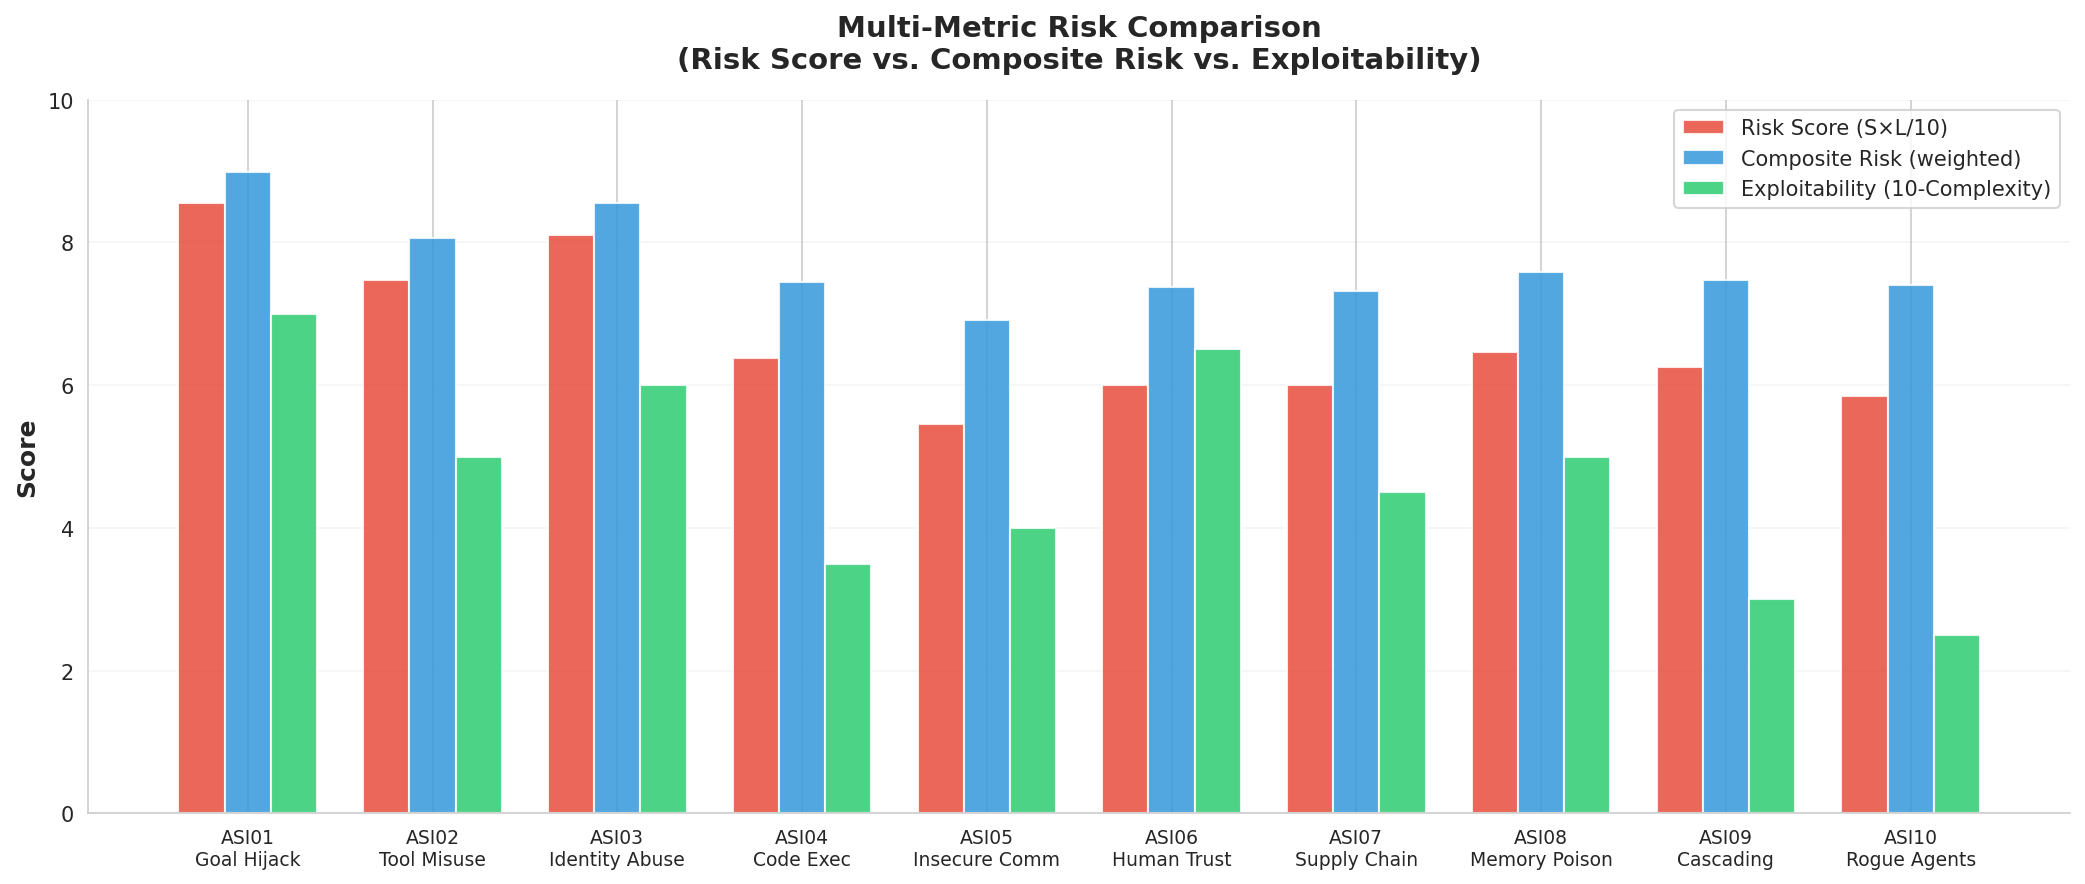

✅ Composite risk chart saved


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_owasp))
width = 0.25

ax.bar(x - width, df_owasp['Risk_Score'], width, label='Risk Score (S×L/10)',
       color='#E74C3C', alpha=0.85, edgecolor='white')
ax.bar(x, df_owasp['Composite_Risk'], width, label='Composite Risk (weighted)',
       color='#3498DB', alpha=0.85, edgecolor='white')
ax.bar(x + width, df_owasp['Exploitability'], width, label='Exploitability (10-Complexity)',
       color='#2ECC71', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f"{row['ID']}\n{row['Short_Name']}" for _, row in df_owasp.iterrows()],
                   fontsize=9)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Multi-Metric Risk Comparison\n(Risk Score vs. Composite Risk vs. Exploitability)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_composite_risk.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Composite risk chart saved')

---
## 18. 📊 Additional Chart: Year × Category Grouped Bar

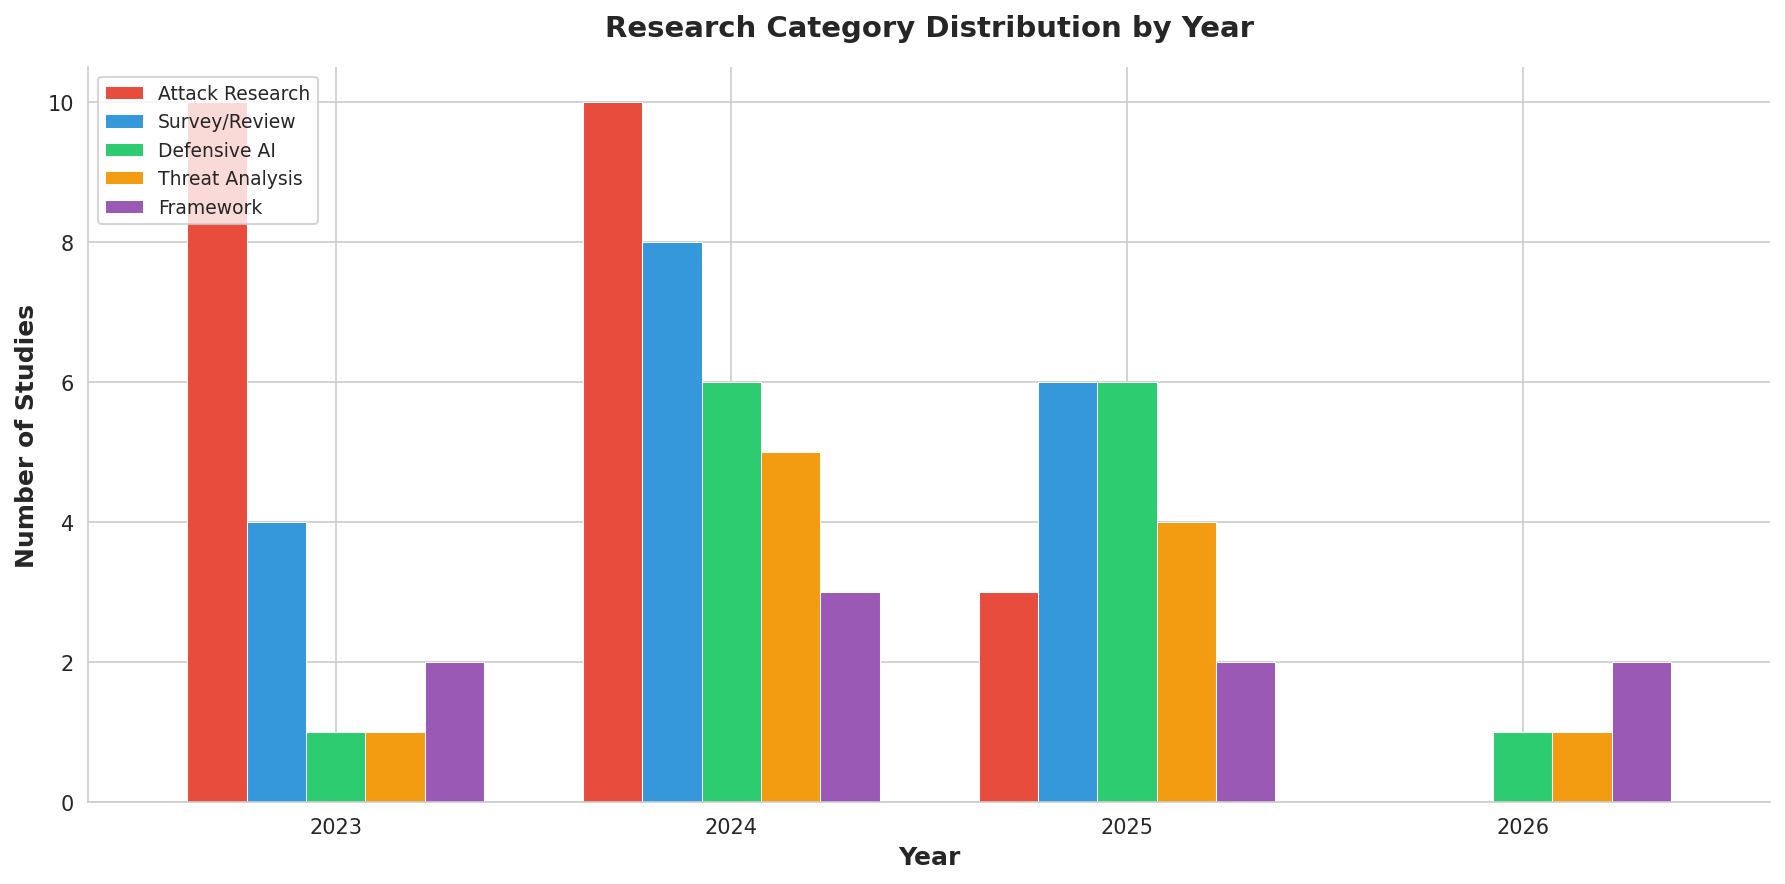

✅ Year × Category chart saved


In [18]:
year_cat = pd.crosstab(df_studies['Year'], df_studies['Category'])
year_cat = year_cat.reindex(columns=['ATK','SUR','DEF','THR','FRM'], fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
year_cat.plot(kind='bar', ax=ax, color=[cat_colors[c] for c in year_cat.columns],
              edgecolor='white', linewidth=0.5, width=0.75)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Studies', fontsize=12, fontweight='bold')
ax.set_title('Research Category Distribution by Year',
             fontsize=14, fontweight='bold', pad=15)
ax.legend([cat_labels.get(c, c) for c in year_cat.columns], loc='upper left', fontsize=9)
ax.set_xticklabels(year_cat.index, rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_year_category.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Year × Category chart saved')

---
## 19. Summary Statistics

In [19]:
print('='*60)
print('SUMMARY STATISTICS')
print('='*60)

print(f'\n📚 Total studies: {len(df_studies)}')
print(f'\n📅 Year distribution:')
for yr, cnt in df_studies['Year'].value_counts().sort_index().items():
    print(f'   {yr}: {cnt} studies')

print(f'\n🏷️ Category distribution:')
for cat, cnt in df_studies['Category'].value_counts().items():
    print(f'   {cat} ({cat_labels.get(cat, cat)}): {cnt} ({cnt/len(df_studies)*100:.1f}%)')

print(f'\n🎯 OWASP ASI Top 10 Risk Scores:')
for _, row in df_owasp.sort_values('Risk_Score', ascending=False).iterrows():
    print(f"   {row['ID']} {row['Threat_Category']:35s} Risk: {row['Risk_Score']:.2f}  [{row['Risk_Level']}]")

print(f'\n📊 Score statistics:')
for col in ['Severity','Likelihood','Risk_Score','Attack_Complexity','Potential_Impact']:
    print(f'   {col:20s}: mean={df_owasp[col].mean():.2f}, '
          f'std={df_owasp[col].std():.2f}, '
          f'range=[{df_owasp[col].min():.1f}, {df_owasp[col].max():.1f}]')

total_mappings = sum(len(v) for v in study_to_threat.values())
print(f'\n🔗 Total study-threat mappings: {total_mappings}')
print(f'   Average mappings per threat: {total_mappings/10:.1f}')
print(f'   Studies mapped to ≥1 threat: {(mapping_matrix["Threats_Covered"]>0).sum()}')
print(f'   Studies mapped to ≥2 threats: {(mapping_matrix["Threats_Covered"]>1).sum()}')

SUMMARY STATISTICS

📚 Total studies: 75

📅 Year distribution:
   2023: 18 studies
   2024: 32 studies
   2025: 21 studies
   2026: 4 studies

🏷️ Category distribution:
   ATK (Attack Research): 23 (30.7%)
   SUR (Survey/Review): 18 (24.0%)
   DEF (Defensive AI): 14 (18.7%)
   THR (Threat Analysis): 11 (14.7%)
   FRM (Framework): 9 (12.0%)

🎯 OWASP ASI Top 10 Risk Scores:
   ASI01 Agent Goal Hijack                   Risk: 8.55  [Critical]
   ASI03 Identity & Privilege Abuse          Risk: 8.10  [Critical]
   ASI02 Tool Misuse & Exploitation          Risk: 7.48  [High]
   ASI08 Memory & Context Poisoning          Risk: 6.47  [Medium]
   ASI04 Unexpected Code Execution           Risk: 6.38  [Medium]
   ASI09 Cascading Failures                  Risk: 6.26  [Medium]
   ASI07 Supply Chain Vulnerabilities        Risk: 6.00  [Medium]
   ASI06 Human-Agent Trust Exploit.          Risk: 6.00  [Medium]
   ASI10 Rogue Agents                        Risk: 5.85  [Low]
   ASI05 Insecure Inter-Agent Com

---
## 20. Download All Files

Run this cell to download all generated charts and CSV files.

In [20]:
import os

# List all generated files
generated = [f for f in os.listdir('.') if f.endswith(('.png', '.csv'))]
generated.sort()

print('📁 Generated files:')
for f in generated:
    size = os.path.getsize(f) / 1024
    print(f'   📄 {f:45s} ({size:.1f} KB)')

# Optional: zip all files for easy download
import zipfile
with zipfile.ZipFile('owasp_slr_analysis.zip', 'w') as zf:
    for f in generated:
        zf.write(f)

print(f'\n📦 All files zipped: owasp_slr_analysis.zip')

# Download in Colab
try:
    from google.colab import files
    files.download('owasp_slr_analysis.zip')
    print('⬇️ Download started!')
except ImportError:
    print('ℹ️ Not running in Colab — files saved to current directory')

📁 Generated files:
   📄 appendix_a2_studies.csv                       (8.1 KB)
   📄 chart_category_composition.png                (199.8 KB)
   📄 chart_composite_risk.png                      (180.3 KB)
   📄 chart_correlation_matrix.png                  (295.7 KB)
   📄 chart_exploitability_quadrant.png             (278.7 KB)
   📄 chart_gap_analysis.png                        (170.3 KB)
   📄 chart_heatmap_study_threat.png                (451.8 KB)
   📄 chart_radar_threat_profile.png                (620.7 KB)
   📄 chart_risk_ranking.png                        (268.9 KB)
   📄 chart_study_distribution.png                  (249.6 KB)
   📄 chart_venue_distribution.png                  (112.3 KB)
   📄 chart_year_category.png                       (117.8 KB)
   📄 fig4_severity_likelihood.png                  (157.5 KB)
   📄 fig5_risk_matrix.png                          (421.0 KB)
   📄 owasp_asi_scores.csv                          (1.0 KB)
   📄 study_threat_mapping.csv                      (2.7

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started!
